In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress

from helpers import get_rec_connectivity,get_influence_dist,compute_params_scan,get_plausible_bool,\
                        compute_infl_gain,get_ncorr_schem,get_infl_vs_ncorr,fit_infl_ncorr_slopes

# Set style

In [2]:
STYLE = {
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "lines.linewidth": 1,
    "axes.linewidth": 0.6,  # Axis border
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3, 
    "figure.figsize": (6.89, 4.8),  # ~wide, tall (full 17.5cm wide)
    "figure.dpi": 300
}

mpl.rcParams.update(STYLE)

# Initialize figure

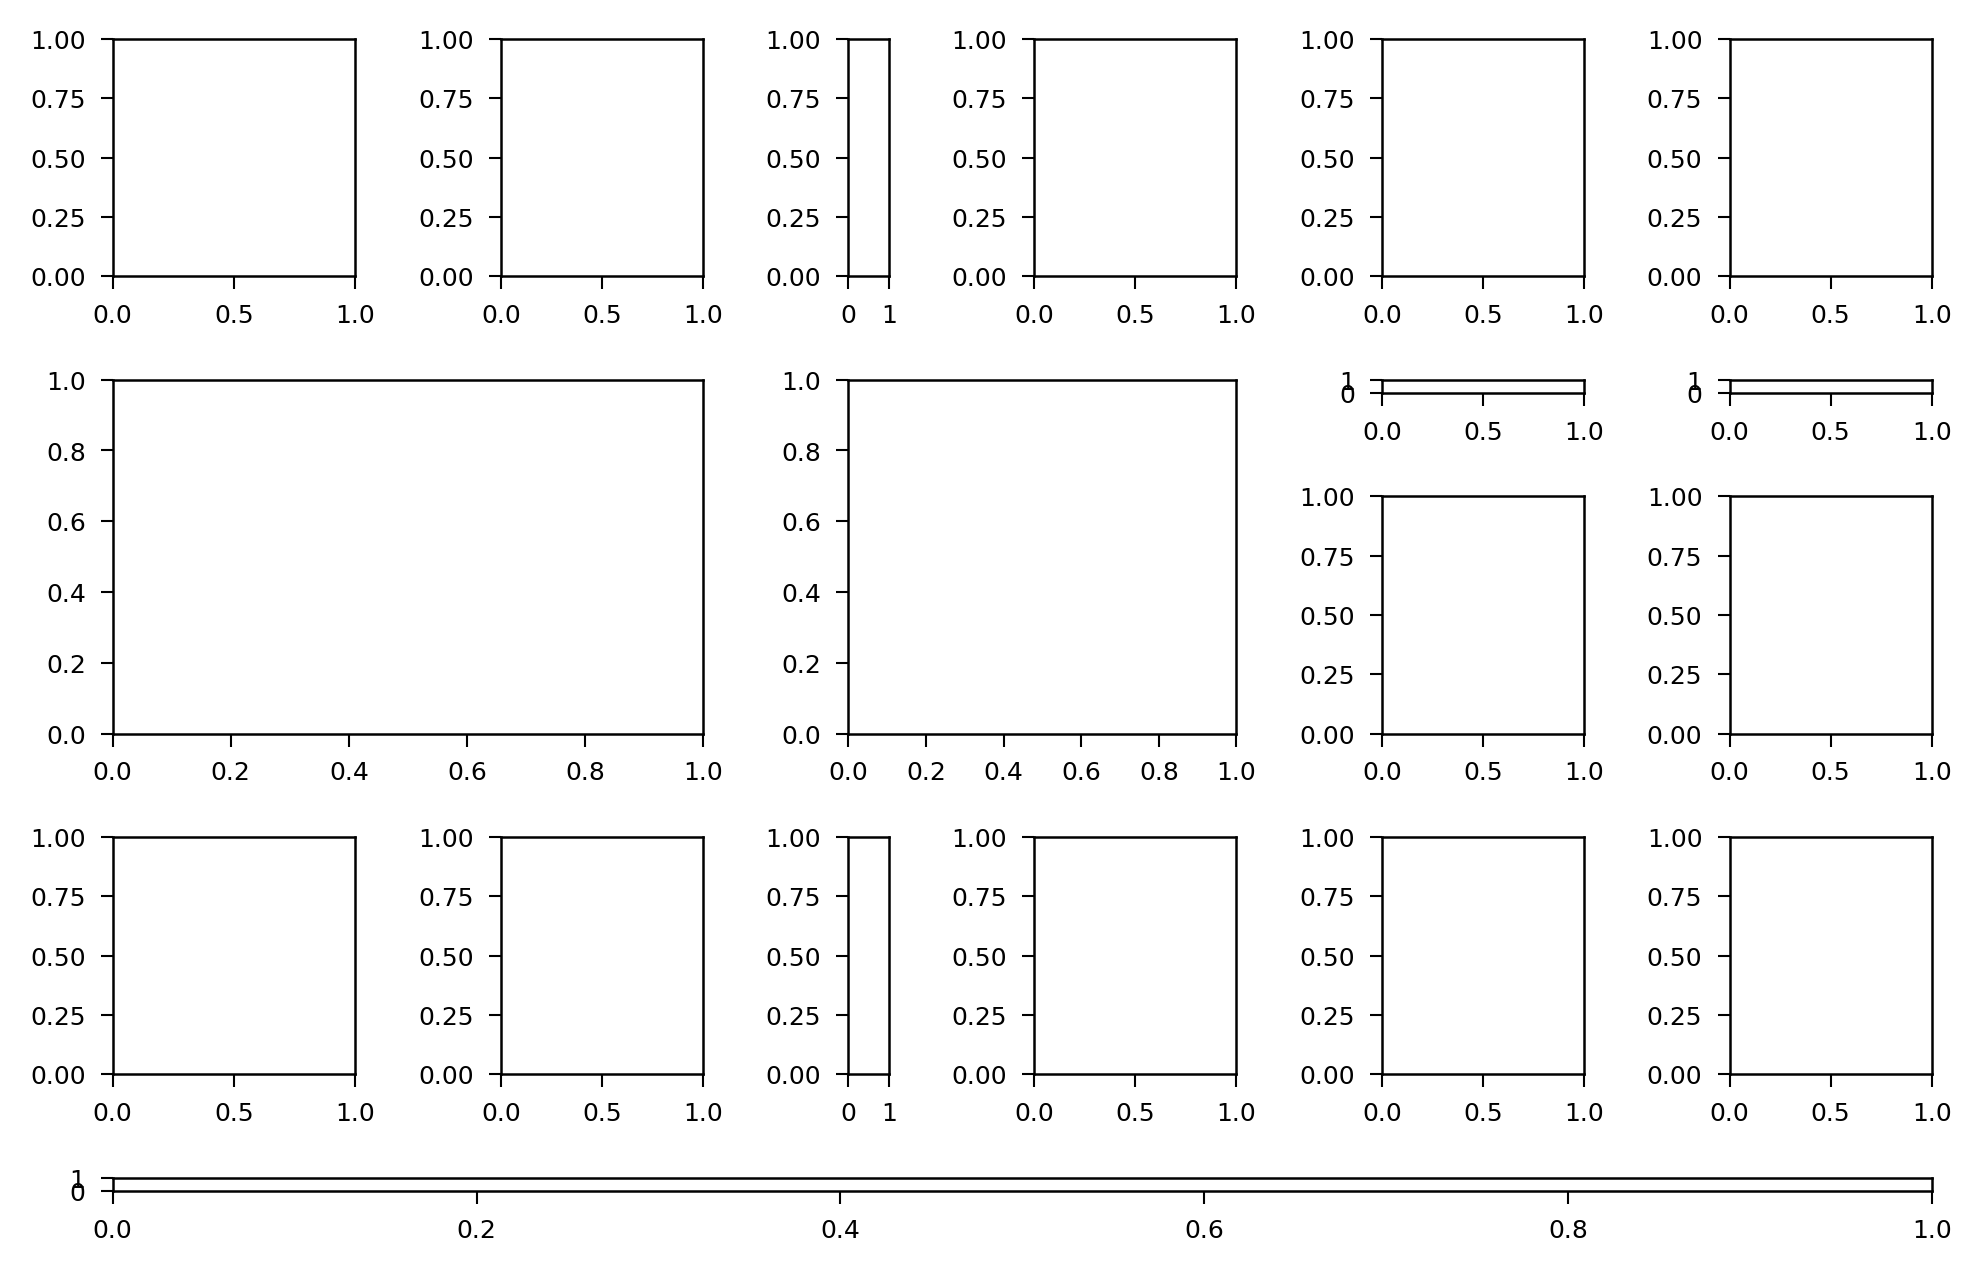

In [3]:
layout = [
    ['a',     'b',      'b_legend', 'b1', 'c',   'c1'],
    ['d',     'd',      'e',        'e',  'f_legend', 'g_legend'],
    ['d',     'd',      'e',        'e',  'f',   'g'],
    ['h',     'i',      'j',        'k',   'l',  'm'],
    [None,    None,     None,       None,   None,  None],
    # ['ncorr', 'j',      'j',        'i2', 'i3',  None]
]
width_ratios = [1.2, 1, 0.2, 1, 1, 1]
height_ratios = [0.9,0.05, 0.9, 0.9, 0.05]
# height_ratios = [0.9,0.05, 0.9, 0.9]

fig = plt.figure()

# Use subplot_mosaic without subplot_kw
axes = fig.subplot_mosaic(
    layout,
    width_ratios=width_ratios,
    height_ratios=height_ratios,
    sharex=False,
    sharey=False
)

# Reduce vertical spacing globally
fig.subplots_adjust(left=0.1, right=0.98, top=1.1, bottom=0.3, wspace=0.8, hspace=0.7)


## No axis for schematics

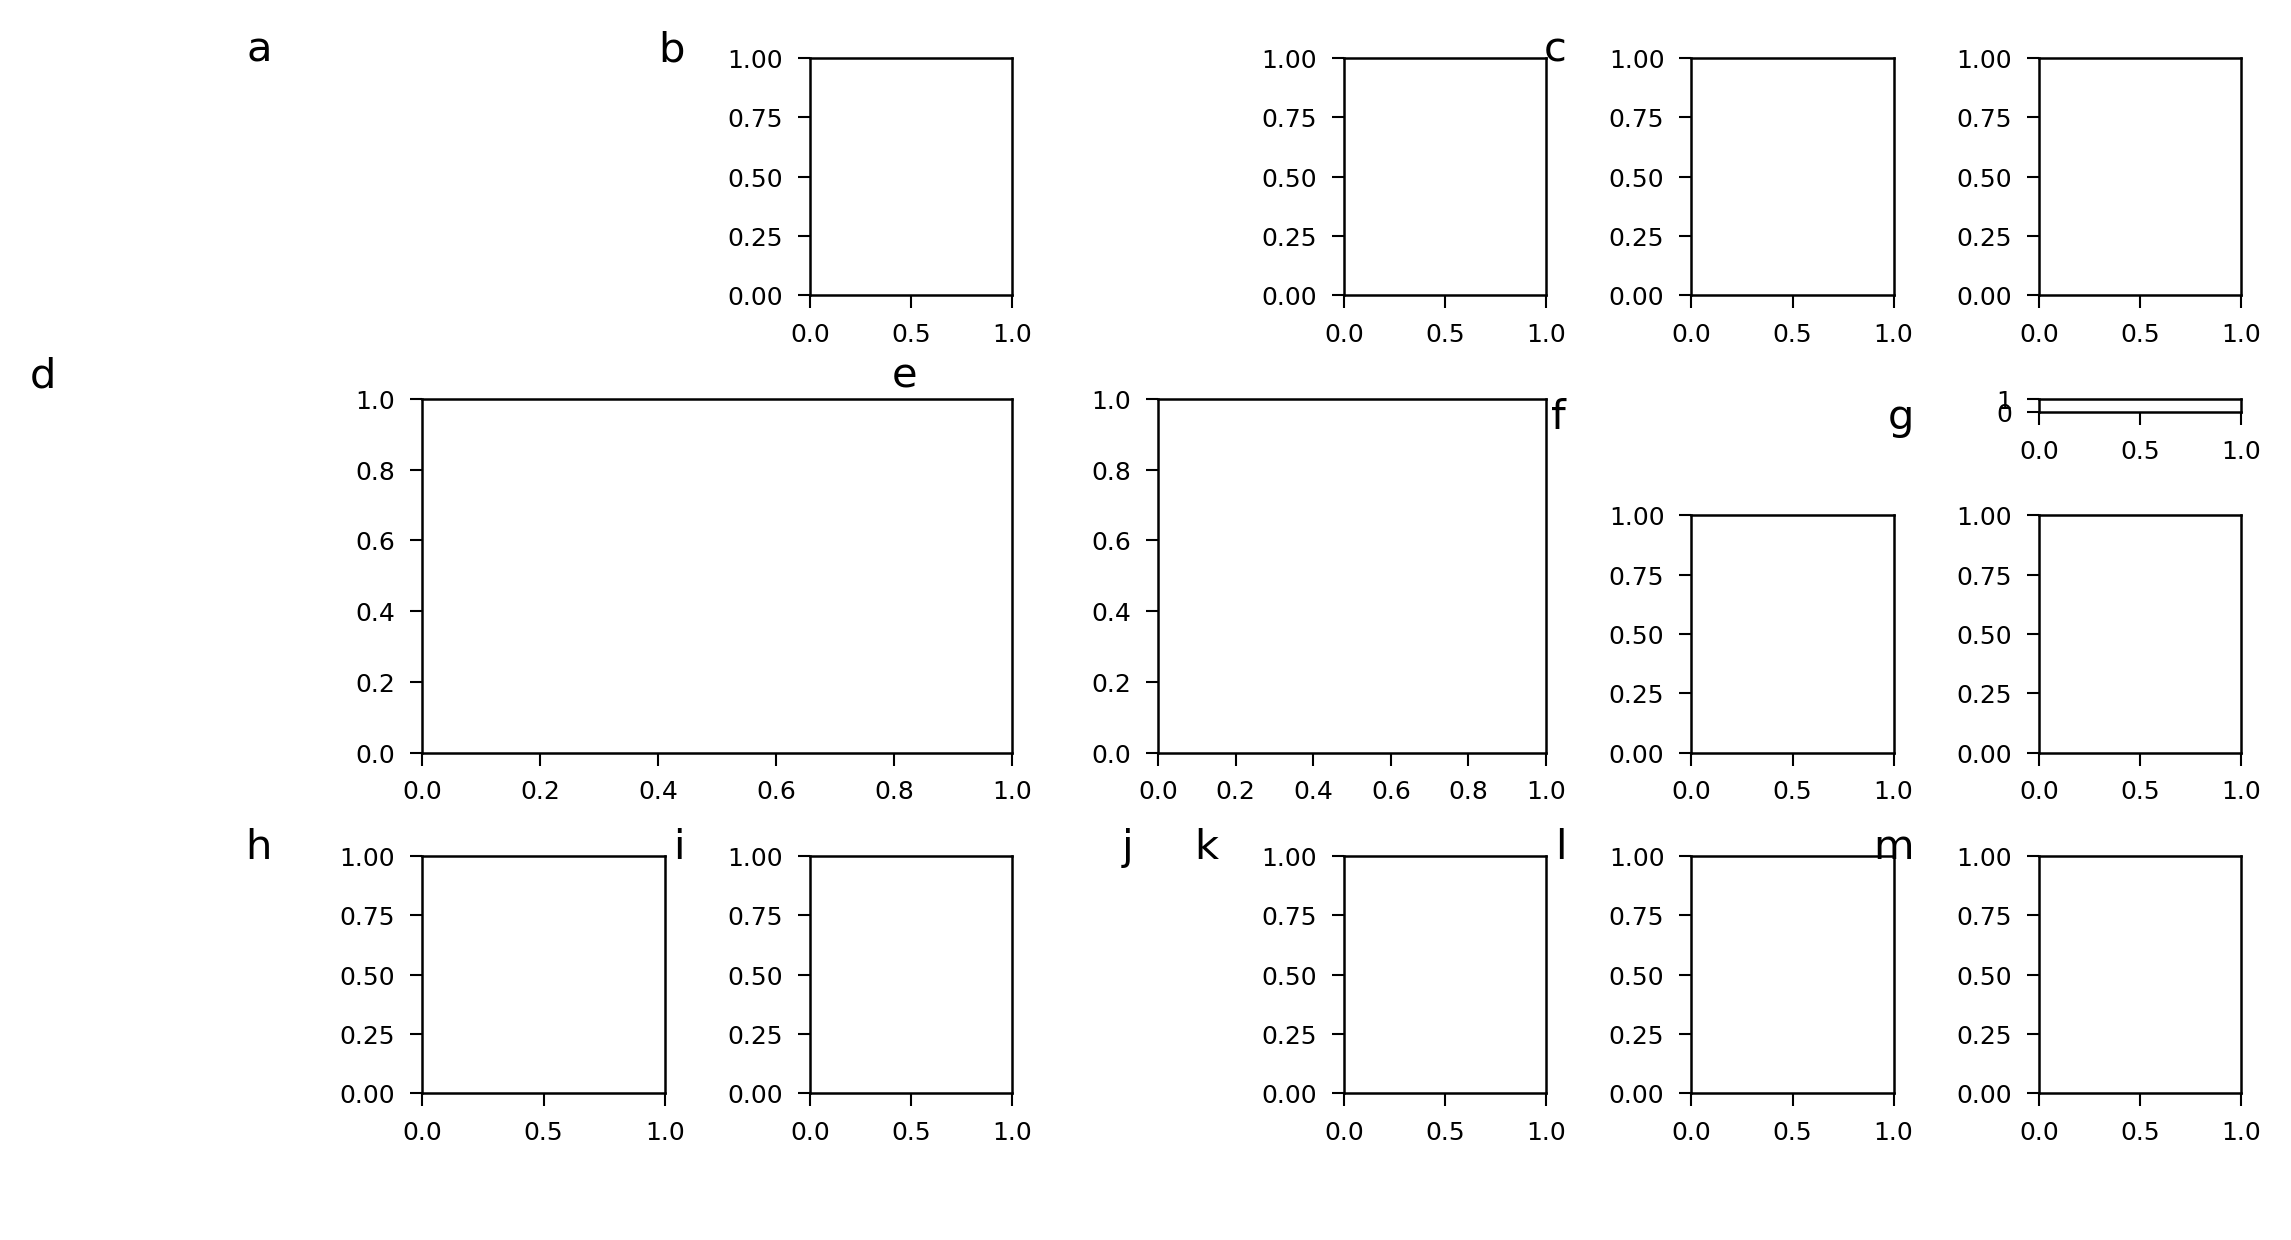

<Figure size 2067x1440 with 0 Axes>

In [4]:
panel_labels = {
    "a": "a",
    "b": "b",
    "b1": None,
    "b_legend": None,  # no label here
    "c": "c",
    "c1": None,
    "d": "d",
    "e": "e",
    "f_legend":"f",
    "g_legend":"g",
    "f": None,
    "g": None,
    "h": "h",
    "i": "i",
    "j": 'j',
    # "i2": None,
    # "i3": None,
    "k":"k",
    "l":"l",
    "m":"m",
    
}
for key, ax in axes.items():
    # Turn off axis for empty panels and those you explicitly want hidden
    if key in [None, 'a', 'ncorr', 'b_legend','j','f_legend','i_legend','nan']:
        ax.axis('off')
        continue

for key, ax in axes.items():
    label = panel_labels.get(key)
    if label is not None:
        # Get the y-axis label position and place the panel label to the left
        ax.annotate(
            label,
            xy=(-0.62, 1.12),  # adjust x (left) and y (slightly above top)
            xycoords='axes fraction',
            fontsize=10,
            # fontweight='bold',
            va='top',
            ha='right'
        )# === Save or Show ===
plt.tight_layout()
fig

# MH

lambda sigma 15.0
actual lambda 100.0


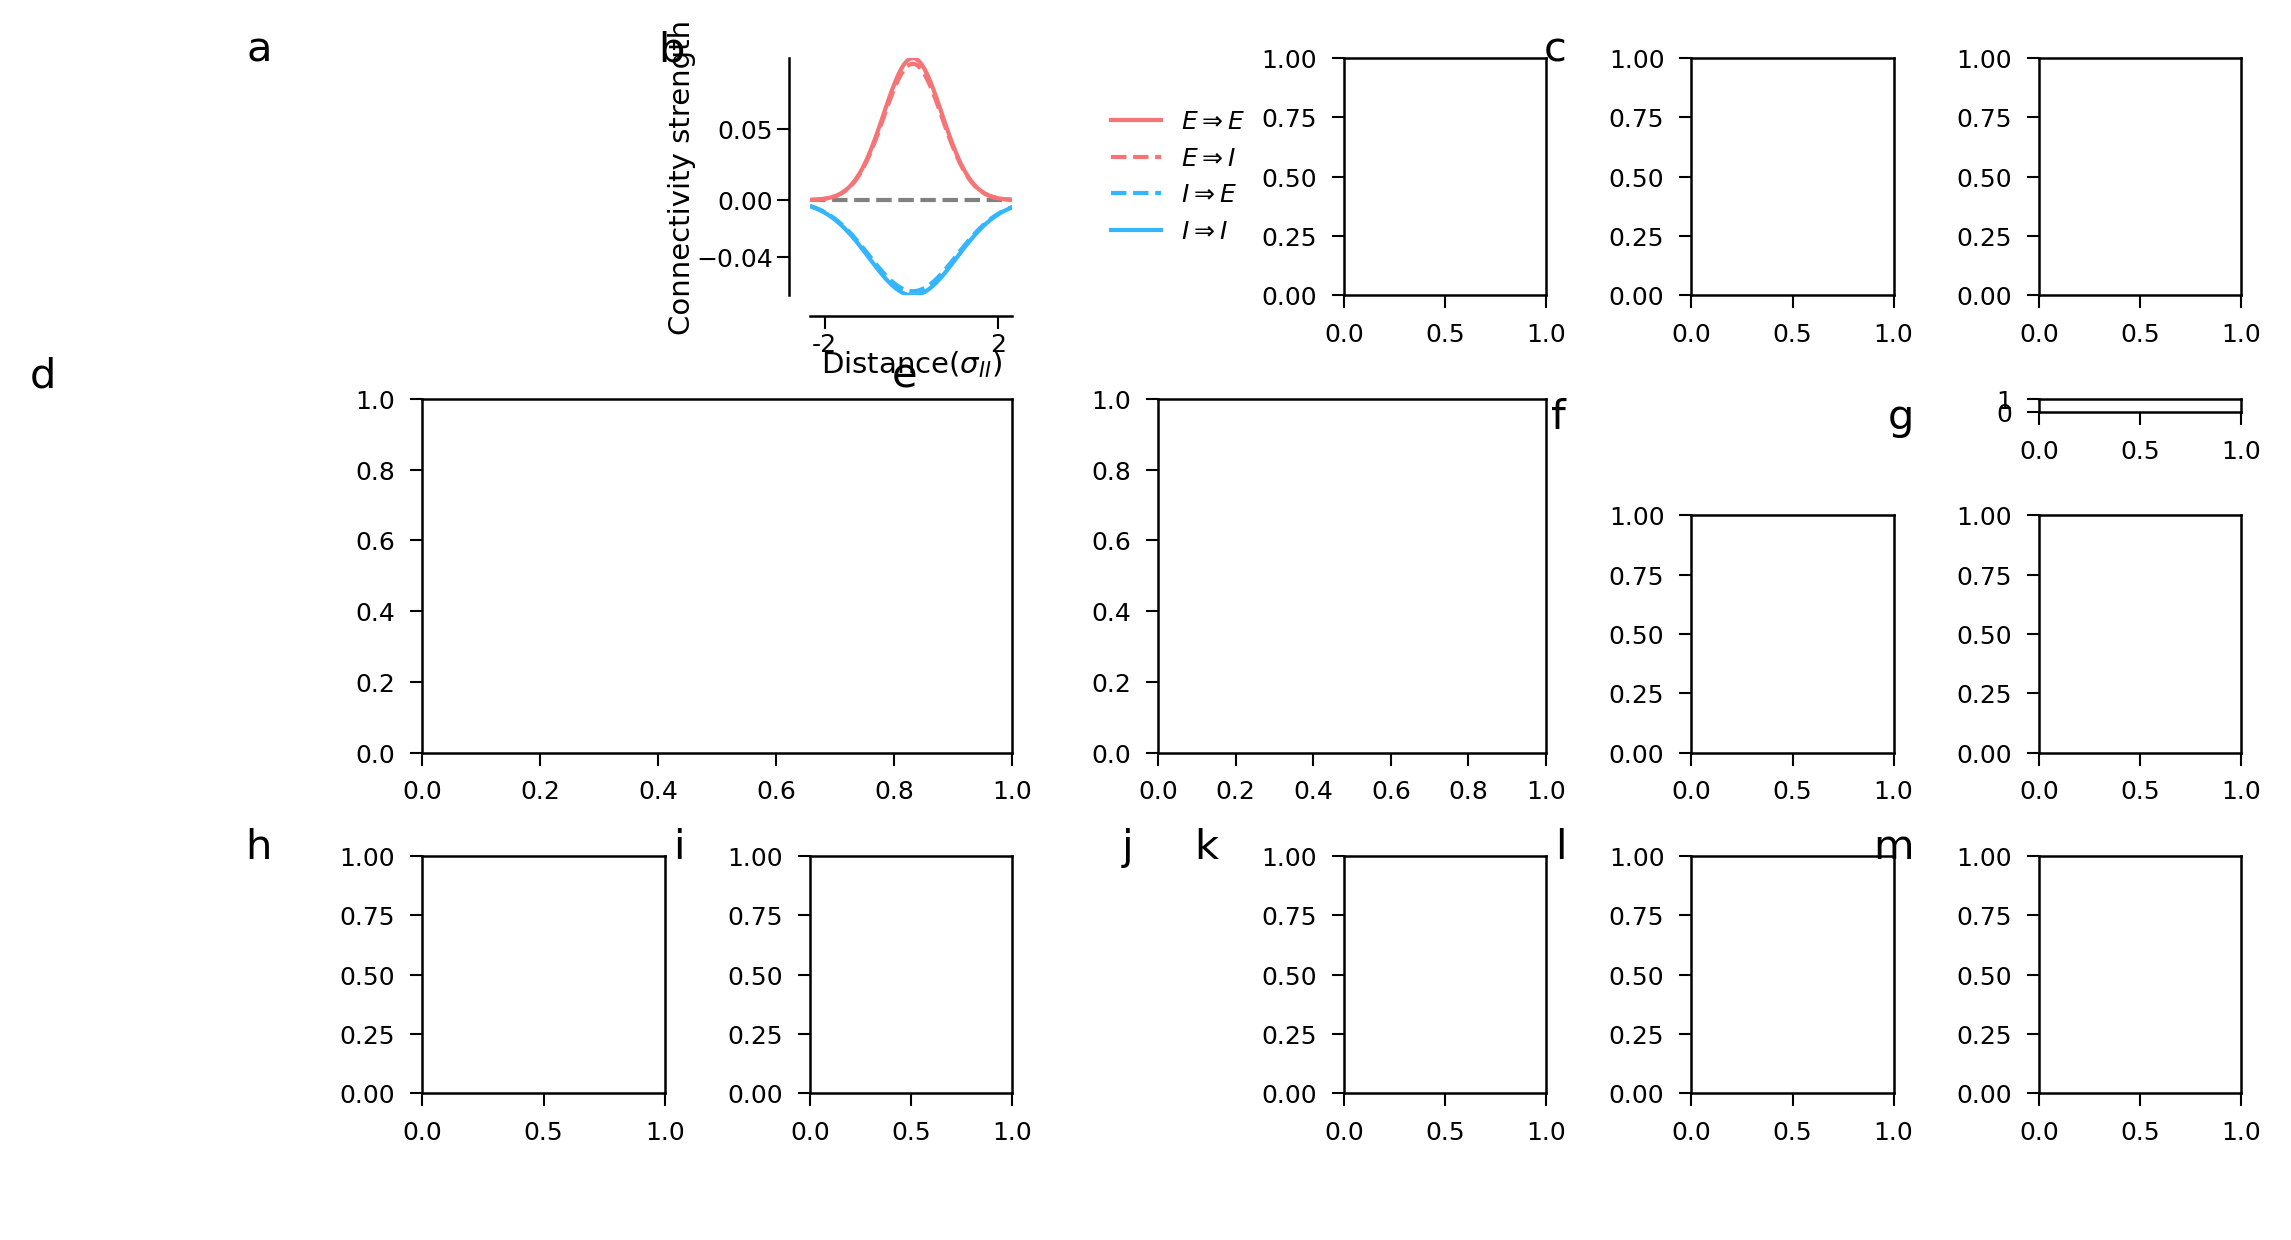

In [5]:
name = 'b'
w,l = get_rec_connectivity('eg_mh')

mee = w[:100,50]
mie = w[100:,50]
mii = w[100:,150]
mei = w[:100,150]

Lambda = 1.5*10
print('lambda sigma',Lambda)
print('actual lambda',l)

x=np.arange(-2*Lambda,2*Lambda,1)

for side in ['top','right']:
    axes[name].spines[side].set_visible(False)

axes[name].spines['bottom'].set_position(('outward', 5))

axes[name].spines['left'].set_position(('outward', 5))


y_max_mee = np.max(mee)
y_min_mii = np.min(mii)



axes[name].set_yticks([-0.04,0,0.05])
axes[name].set_ylim([y_min_mii,y_max_mee])



axes[name].set_ylabel("Connectivity strength",labelpad=0)
axes[name].set_xlabel(r'Distance($\sigma_{II}$)',labelpad=-2)

axes[name].axhline(y=0.00, color='gray', linestyle='--')
x=np.linspace(-50,50,len(mee))
axes[name].plot(x, mee, color='#F57476', label=r'$E \Rightarrow E$')
axes[name].plot(x, mie, color='#F57476', linestyle='--',label=r'$E \Rightarrow I$')
axes[name].plot(x, mei, color='#33B6FD',linestyle='--', label=r'$I \Rightarrow E$')
axes[name].plot(x, mii, color='#33B6FD', label=r'$I \Rightarrow I$')

# Lambda=50
axes[name].set_xticks([-2*Lambda,2*Lambda])
axes[name].set_xticklabels([ '-2', '2'])
axes[name].set_xlim([-2*Lambda-5,2*Lambda+5])
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)

axes['b_legend'].legend(*axes['b'].get_legend_handles_labels(), loc='center', fontsize=6, frameon=False)
fig



Maximum frequency ': 0.20 Hz


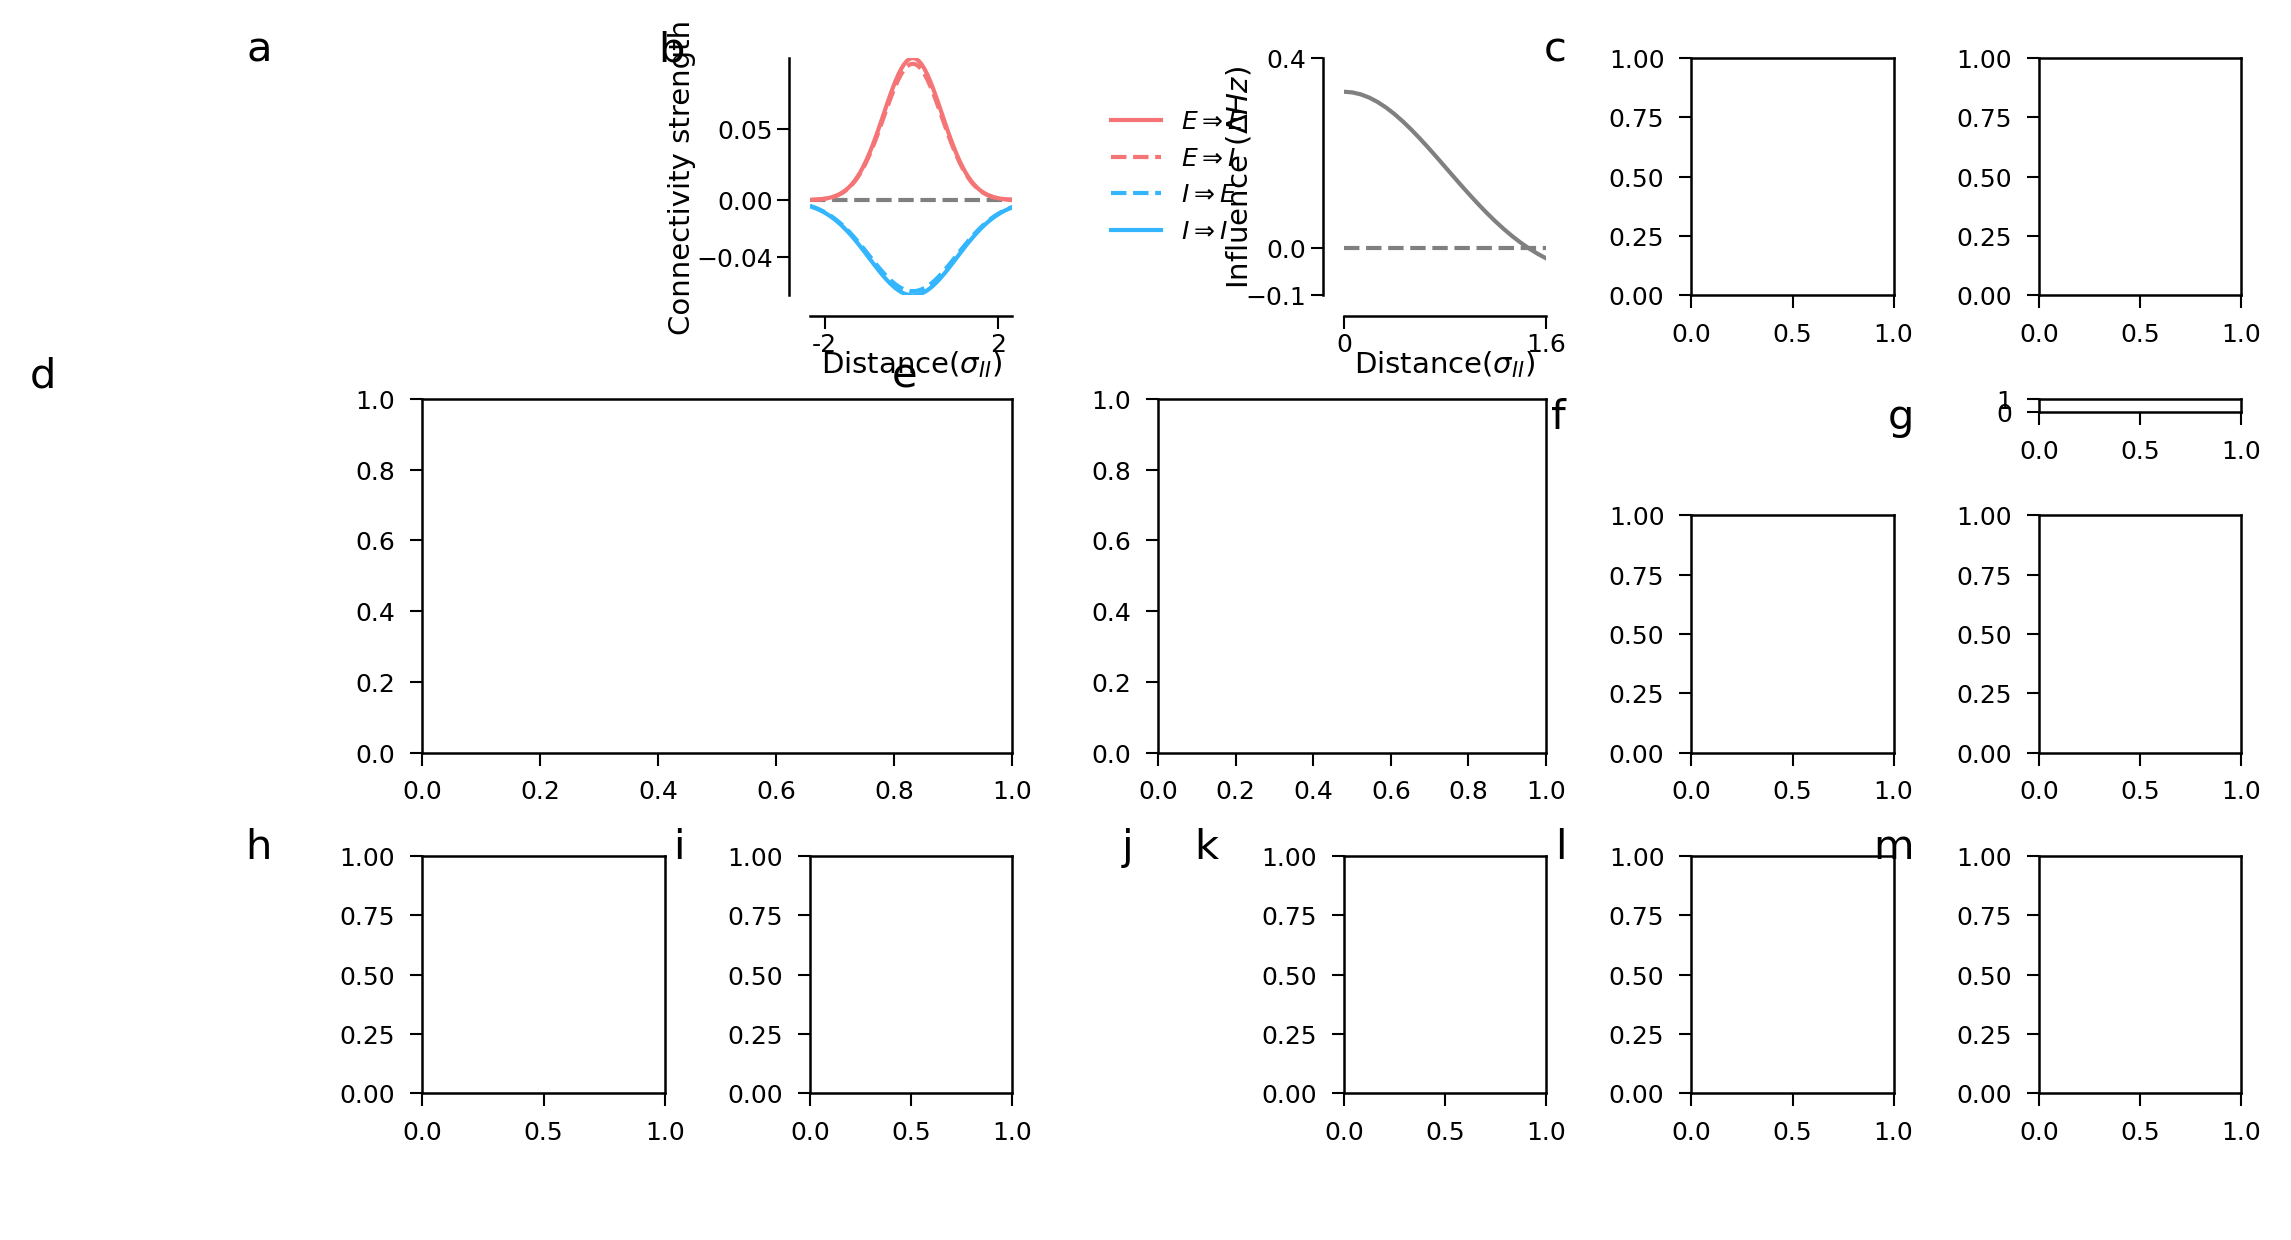

In [6]:
infl = get_influence_dist(keyword='eg_mh')['toE']


name = 'b1'

for side in ['top','right']:
    axes[name].spines[side].set_visible(False)

axes[name].spines['bottom'].set_position(('outward', 5))

axes[name].spines['left'].set_position(('outward', 5))


axes[name].plot(infl,color='grey')

axes[name].set_ylabel(r'Influence ($\Delta Hz$)',labelpad=-2)

axes[name].set_xlabel(r'Distance($\sigma_{II}$)',labelpad=-2)
axes[name].set_yticks([-0.1,0.,0.4])

axes[name].axhline(y=0.00, color='gray', linestyle='--')

Lambda = 1.5*10
axes[name].set_xticks([0.0,1.6*Lambda])
axes[name].set_xticklabels([ '0', '1.6'])
axes[name].set_xlim([0,1.6*Lambda])
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)

fig

# CD

lambda sigma 15.0
actual lambda 33.333333333333336


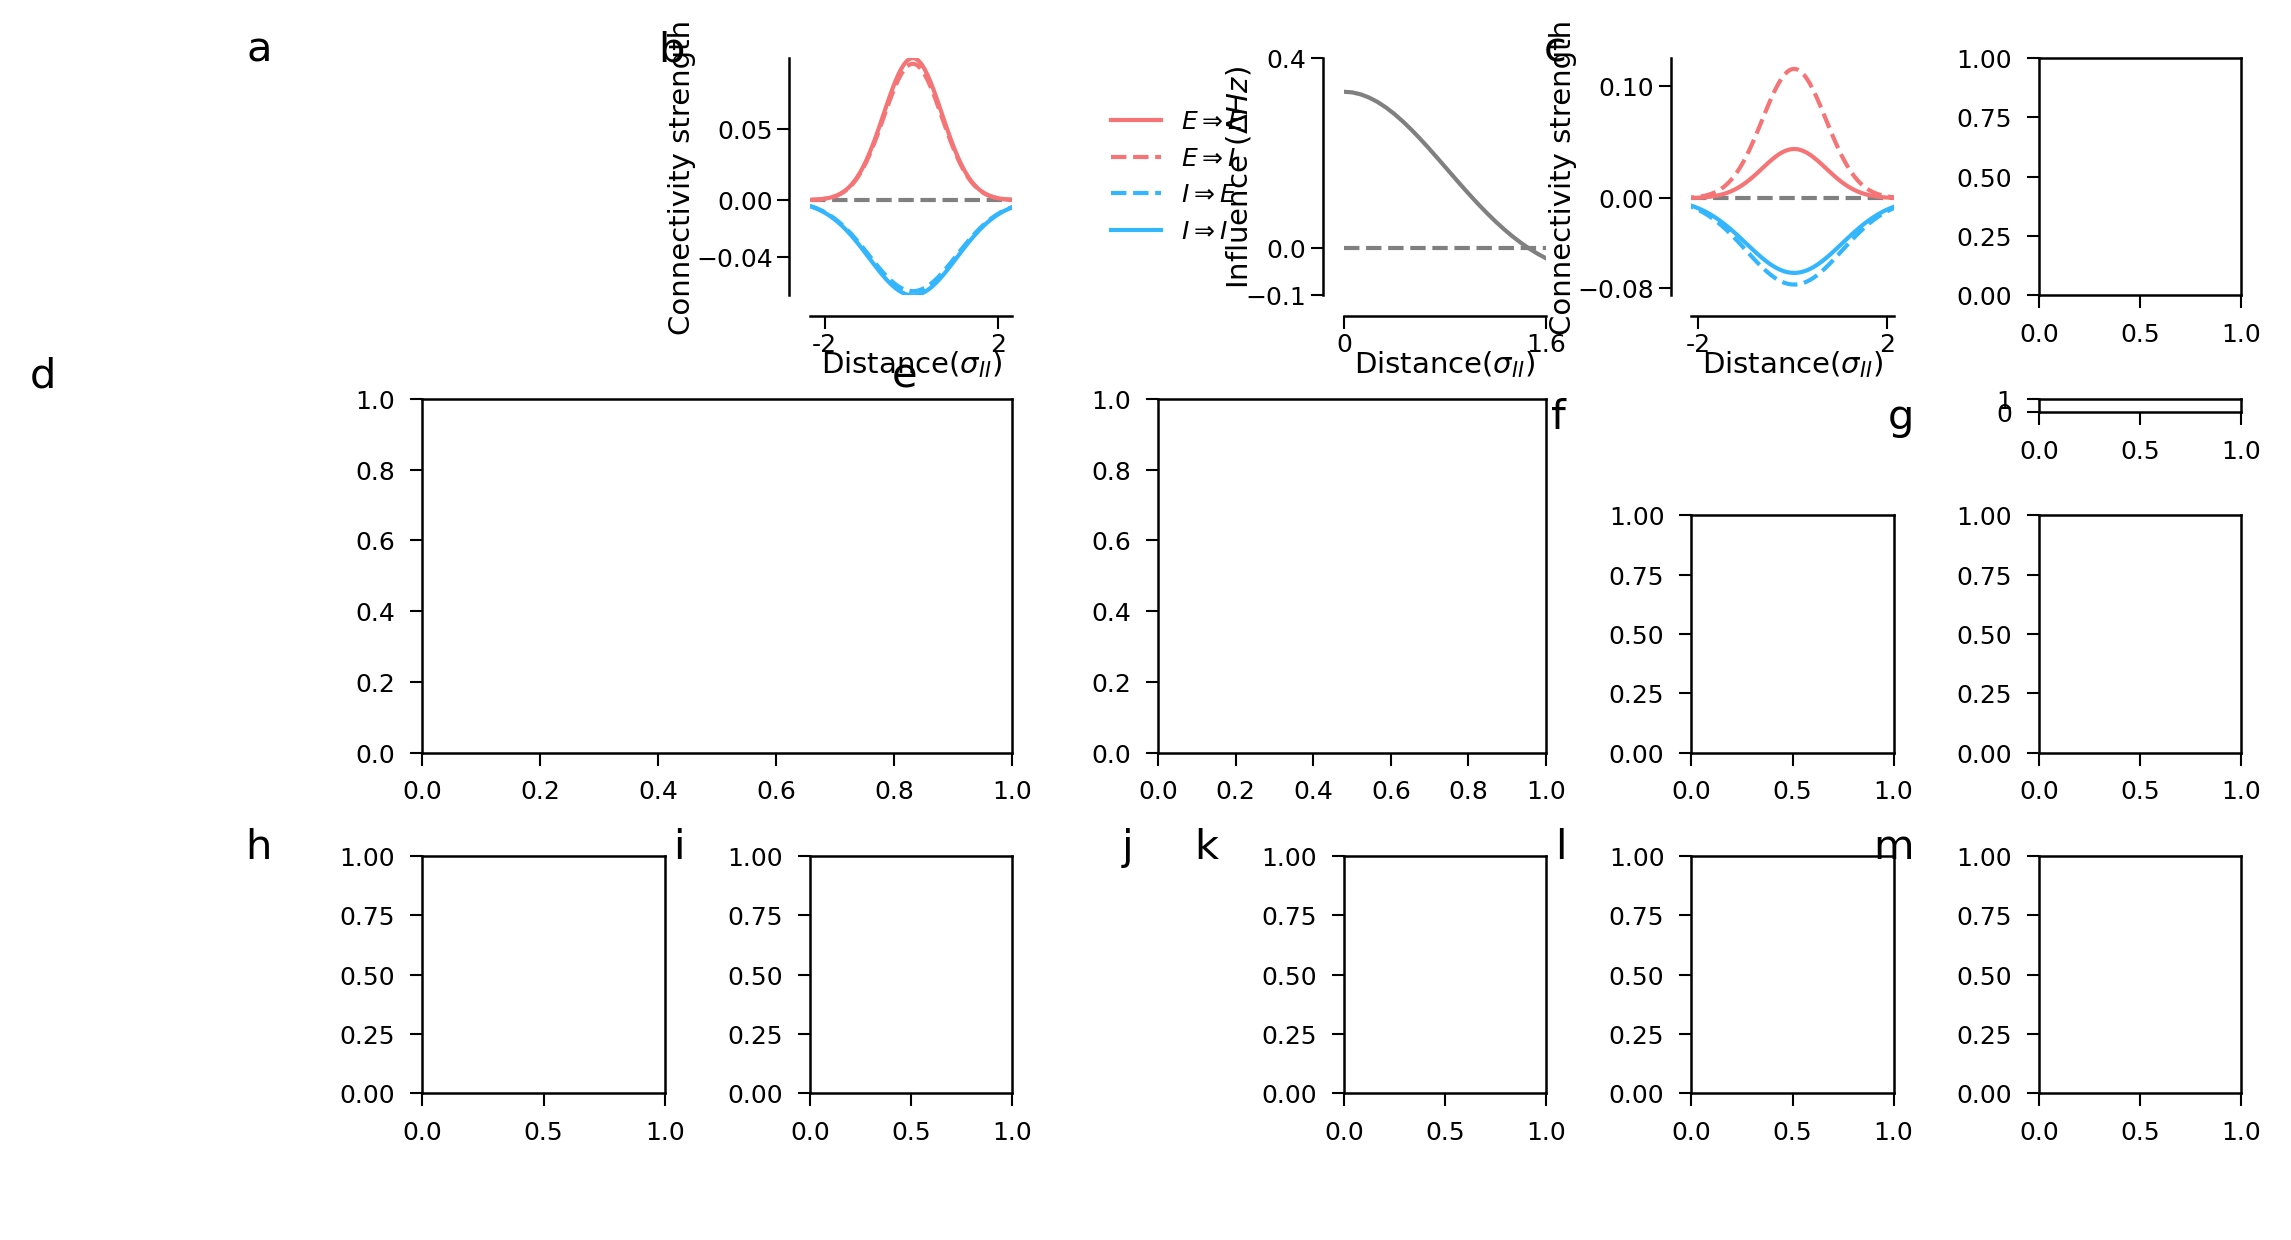

In [7]:
name = 'c'
w,l = get_rec_connectivity('eg_cross_pop')

mee = w[:100,50]
mie = w[100:,50]
mii = w[100:,150]
mei = w[:100,150]

Lambda = 1.5*10
print('lambda sigma',Lambda)
print('actual lambda',l)

x=np.arange(-2*Lambda,2*Lambda,1)
for side in ['top','right']:
    axes[name].spines[side].set_visible(False)

axes[name].spines['bottom'].set_position(('outward', 5))

axes[name].spines['left'].set_position(('outward', 5))


y_max_mee = np.max(mee)
y_min_mii = np.min(mii)



axes[name].set_yticks([-0.08,0,0.1])

ax.set_xticks([-2*Lambda,0,2*Lambda])
axes[name].set_ylabel("Connectivity strength",labelpad=0)
axes[name].set_xlabel(r'Distance($\sigma_{II}$)',labelpad=-2)

axes[name].axhline(y=0.00, color='gray', linestyle='--')
x=np.linspace(-50,50,len(mee))
axes[name].plot(x, mee,  color='#F57476', )
axes[name].plot(x, mie,  color='#F57476', linestyle='--')
axes[name].plot(x, mei,  color='#33B6FD',linestyle='--')
axes[name].plot(x, mii, color='#33B6FD')


axes[name].set_xticks([-2*Lambda,2*Lambda])
axes[name].set_xticklabels([ '-2', '2'])
axes[name].set_xlim([-2*Lambda-2,2*Lambda+2])
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)

fig


Maximum frequency ': 0.60 Hz


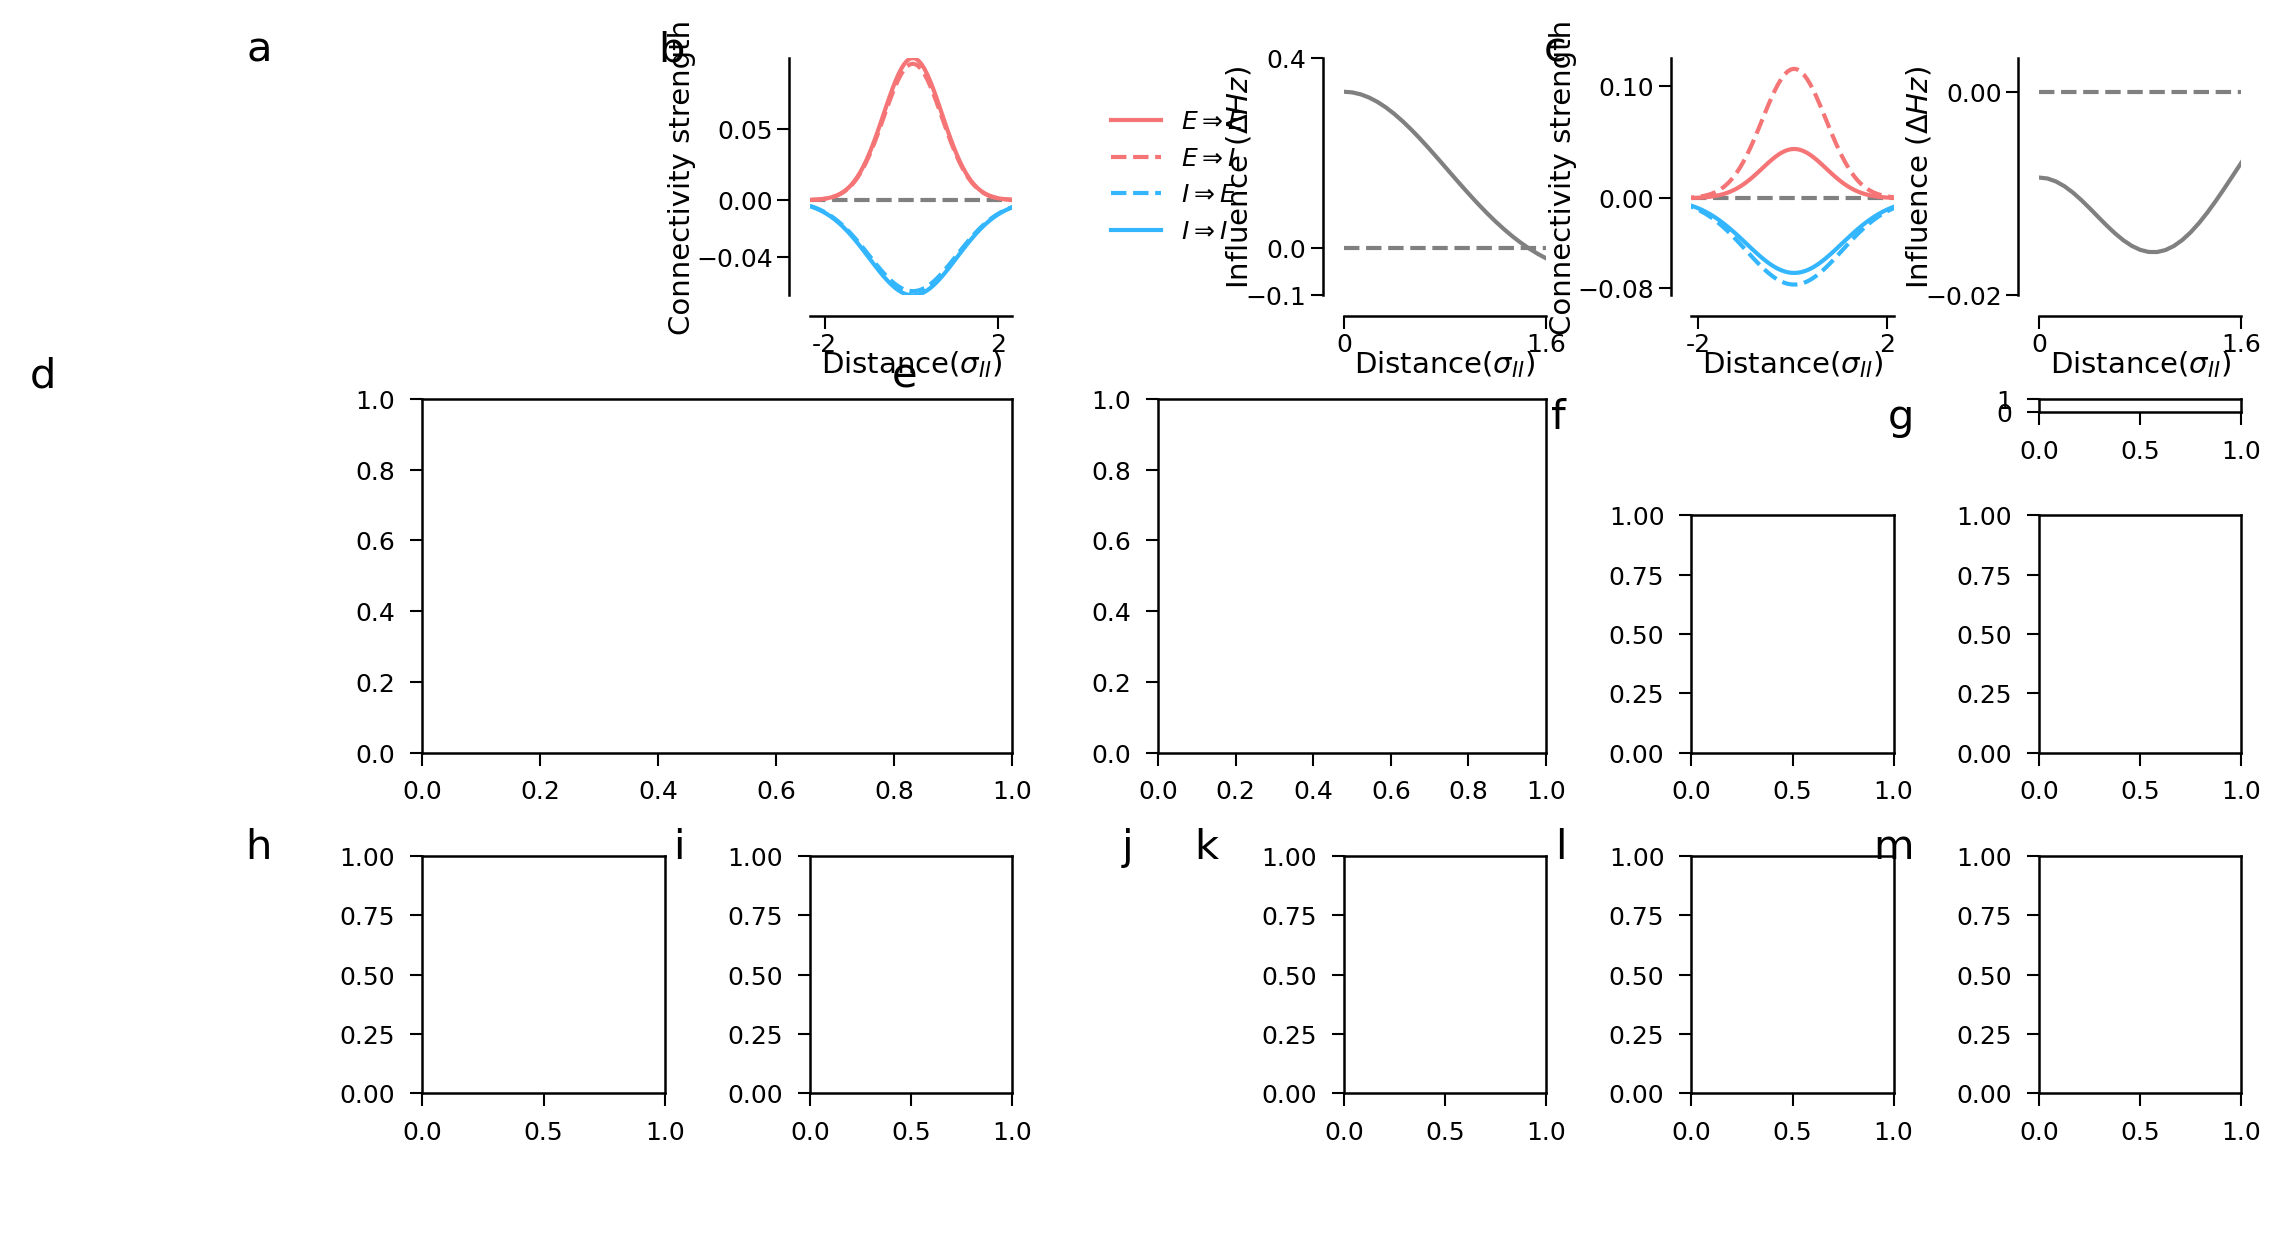

In [8]:
name='c1'
infl = get_influence_dist(keyword='eg_cross_pop')['toE']#[1:]

for side in ['top','right']:
    axes[name].spines[side].set_visible(False)

axes[name].spines['bottom'].set_position(('outward', 5))

axes[name].spines['left'].set_position(('outward', 5))



axes[name].plot(infl,color='grey')

axes[name].set_ylabel(r'Influence ($\Delta Hz$)',labelpad=-2)

axes[name].set_xlabel(r'Distance($\sigma_{II}$)',labelpad=-2)
axes[name].set_yticks([-0.02,0.00])

axes[name].axhline(y=0.00, color='gray', linestyle='--')

axes[name].set_xticks([0.0,1.6*Lambda])
axes[name].set_xticklabels([ '0', '1.6'])
axes[name].set_xlim([0,1.6*Lambda])
# axes[name].set_xlim([0,10])
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)


fig

# Param scan

In [9]:
# simulate 
AverageEE_Infl,StableEE = compute_params_scan()

/Users/fionakong/Downloads/kaschube-lab/Influence_mapping/code_clean/Model/ring.py:1082: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  opto = torch.tensor(opto,dtype=torch.float32)


debug (31, 26)
(31, 26)
(31, 26)
(31, 26)
0.02
(31, 26)
b:  0.049309768
c:  -0.012810725


/var/folders/z8/675cf8pn6s53_cqmkl8jcnyc0000gq/T/ipykernel_12649/3514553842.py:26: UserWarning: Adding colorbar to a different Figure <Figure size 2067x1440 with 20 Axes> than <Figure size 2067x1440 with 0 Axes> which fig.colorbar is called on.
  cb = plt.colorbar(c)


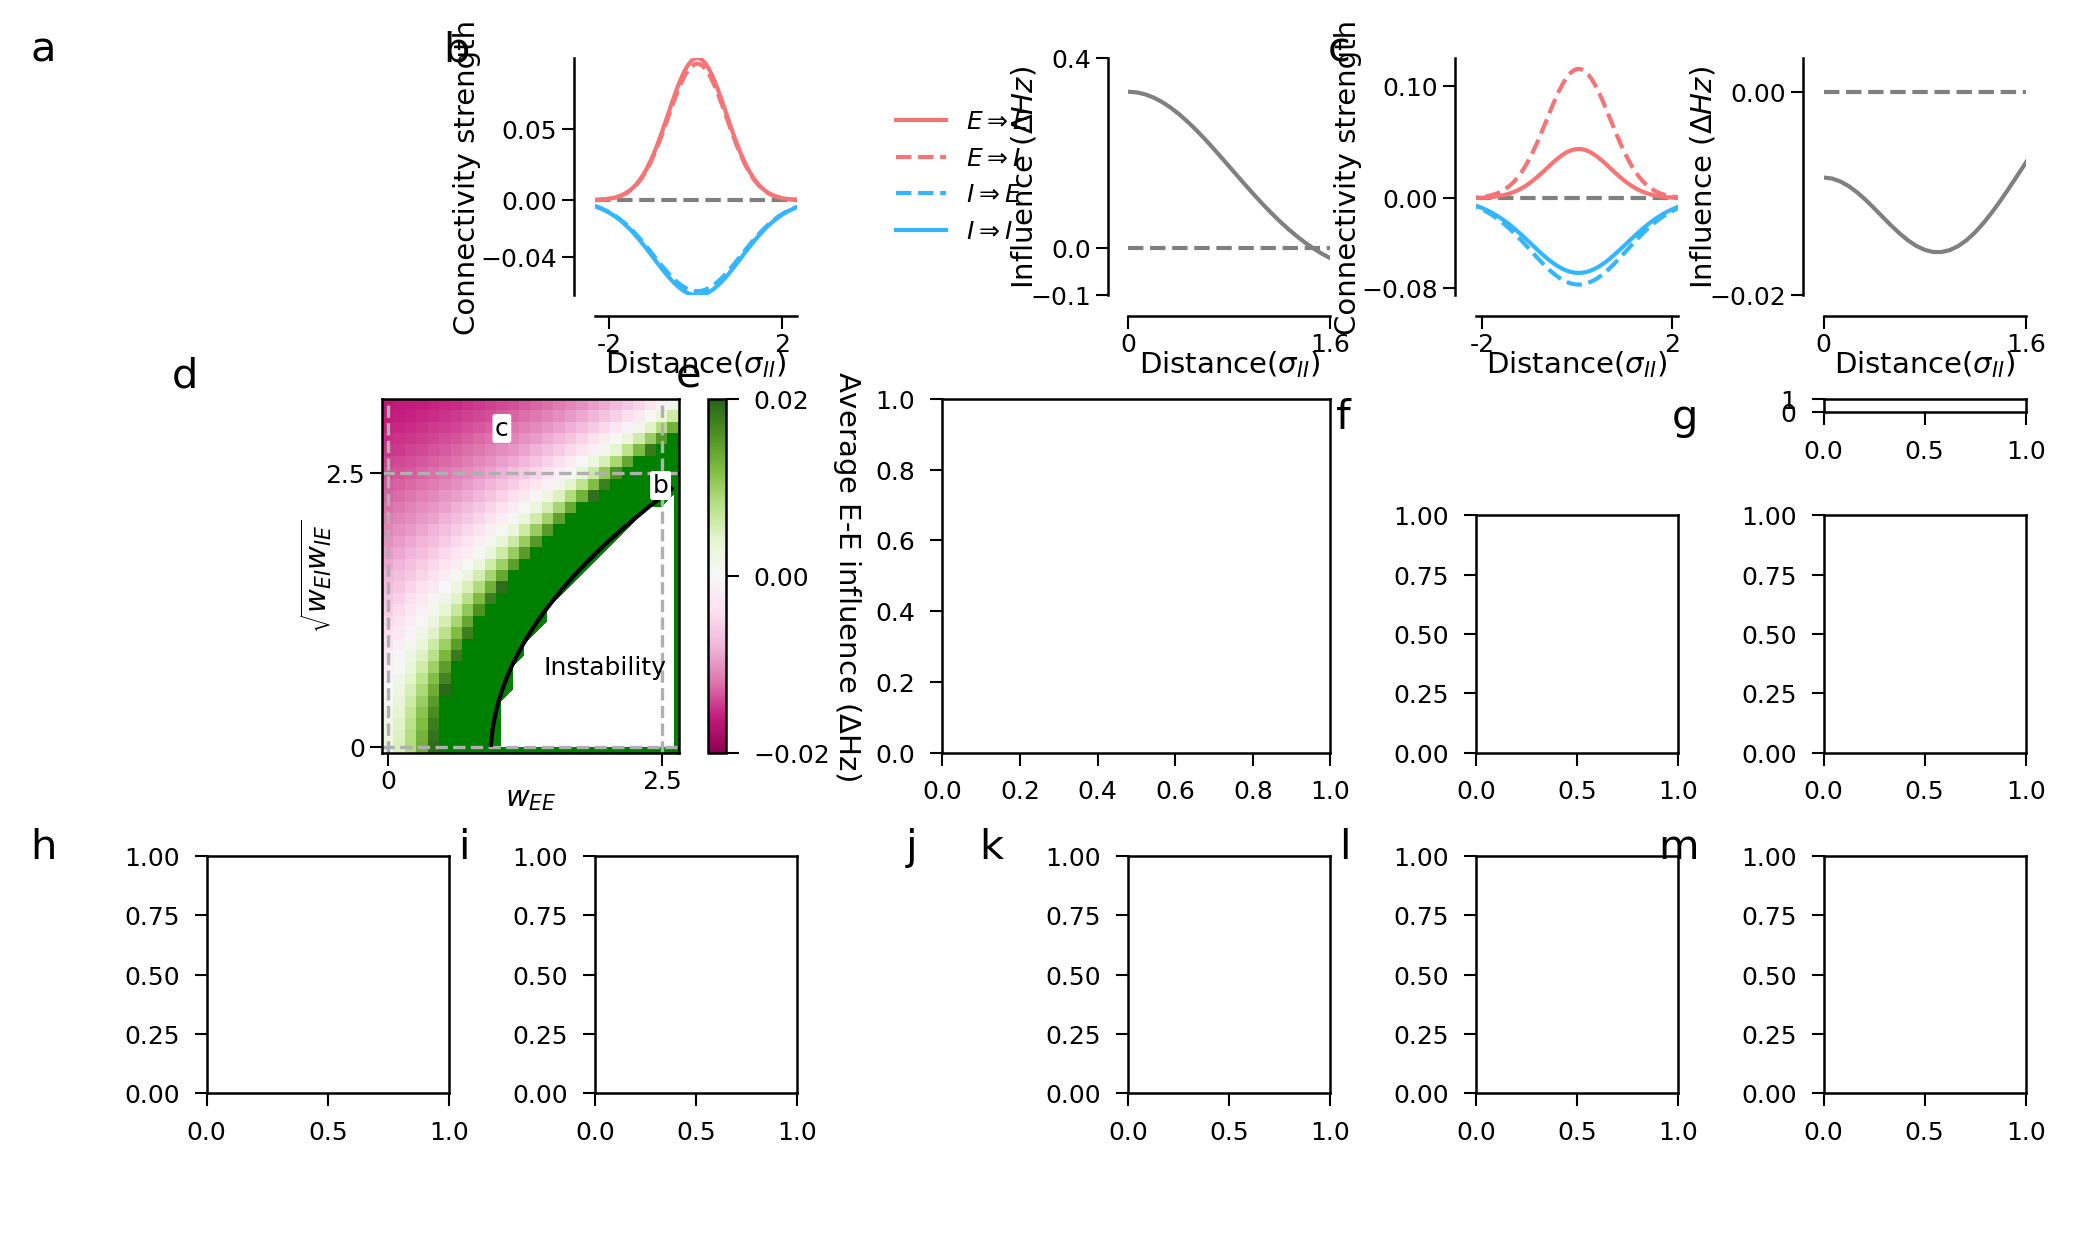

<Figure size 2067x1440 with 0 Axes>

In [10]:
name = 'd'

# Wee=np.arange(0.1,2.5,0.05)
# Wei=np.arange(0.1,2.5,0.05)
Wee=np.arange(0.1,2.7,0.1)
Wei=np.arange(0.1,3.2,0.1)

X, Y = np.meshgrid(Wee, Wei)
print('debug',X.shape)
print(Y.shape)
print(StableEE.shape)
print(AverageEE_Infl.shape)



threshold = 0.02
# SMask= np.ma.masked_where(np.abs(AverageEE_Infl) > threshold, AverageEE_Infl)

# abs_max = np.max(np.abs(SMask))
abs_max = 0.02

# c = axes[name].pcolormesh(X, Y, SMask, shading='auto', cmap='PiYG', vmin=-abs_max, vmax=abs_max)
c = axes[name].pcolormesh(X, Y, AverageEE_Infl, shading='auto', cmap='PiYG', vmin=-abs_max, vmax=abs_max)
print(abs_max)

cb = plt.colorbar(c)
cb.ax.tick_params()

cb.set_ticks([-0.02, 0, 0.02])
cb.set_label(r'Average E-E influence ($\Delta$Hz)',rotation=270,labelpad=8)

masked_area = np.ma.masked_where(np.abs(AverageEE_Infl) <= threshold, np.ones_like(AverageEE_Infl))
axes[name].pcolormesh(X, Y, masked_area, cmap='ocean', shading='auto', alpha=1)
# axes[name].pcolormesh(masked_area, cmap='ocean', shading='auto', alpha=1)

axes[name].grid(True, which='both', linestyle='--', alpha=1)
axes[name].set_ylabel(r'$\sqrt{w_{EI}w_{IE}}$',labelpad=-2)
axes[name].set_xlabel('$w_{EE}$',labelpad=-2)

axes[name].set_xticks([0.1, 2.5], ['$0$', '$2.5$'])
axes[name].set_yticks([0.1, 2.5], ['$0$', '2.5'])


axes[name].contour(X, Y,StableEE, levels=[1], colors='black', linewidths=1)
InstMask= np.ma.masked_where(StableEE<= 1, StableEE)


axes[name].contourf(X, Y, InstMask, hatches=['//'], colors='white')
axes[name].contourf(X, Y, InstMask, levels=[1, StableEE.max()], colors='white')


axes[name].set_aspect('equal')
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)

axes[name].text(
    2.49, 2.39, 'b',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)
print(AverageEE_Infl.shape)
print('b: ',AverageEE_Infl[24, 23])
print('c: ',AverageEE_Infl[29, 11])
axes[name].text(
    1.1, 2.89, 'c',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)
axes[name].text(
    2, 0.8, 'Instability',
    fontsize=6,
    color='black',
    ha='center', va='center'
)

fig

/Users/fionakong/Downloads/kaschube-lab/Influence_mapping/code_clean/Model/ring.py:1082: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  opto = torch.tensor(opto,dtype=torch.float32)
/var/folders/z8/675cf8pn6s53_cqmkl8jcnyc0000gq/T/ipykernel_12649/2259180410.py:18: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[name].grid(False, which='both', linestyle='--', alpha=1)


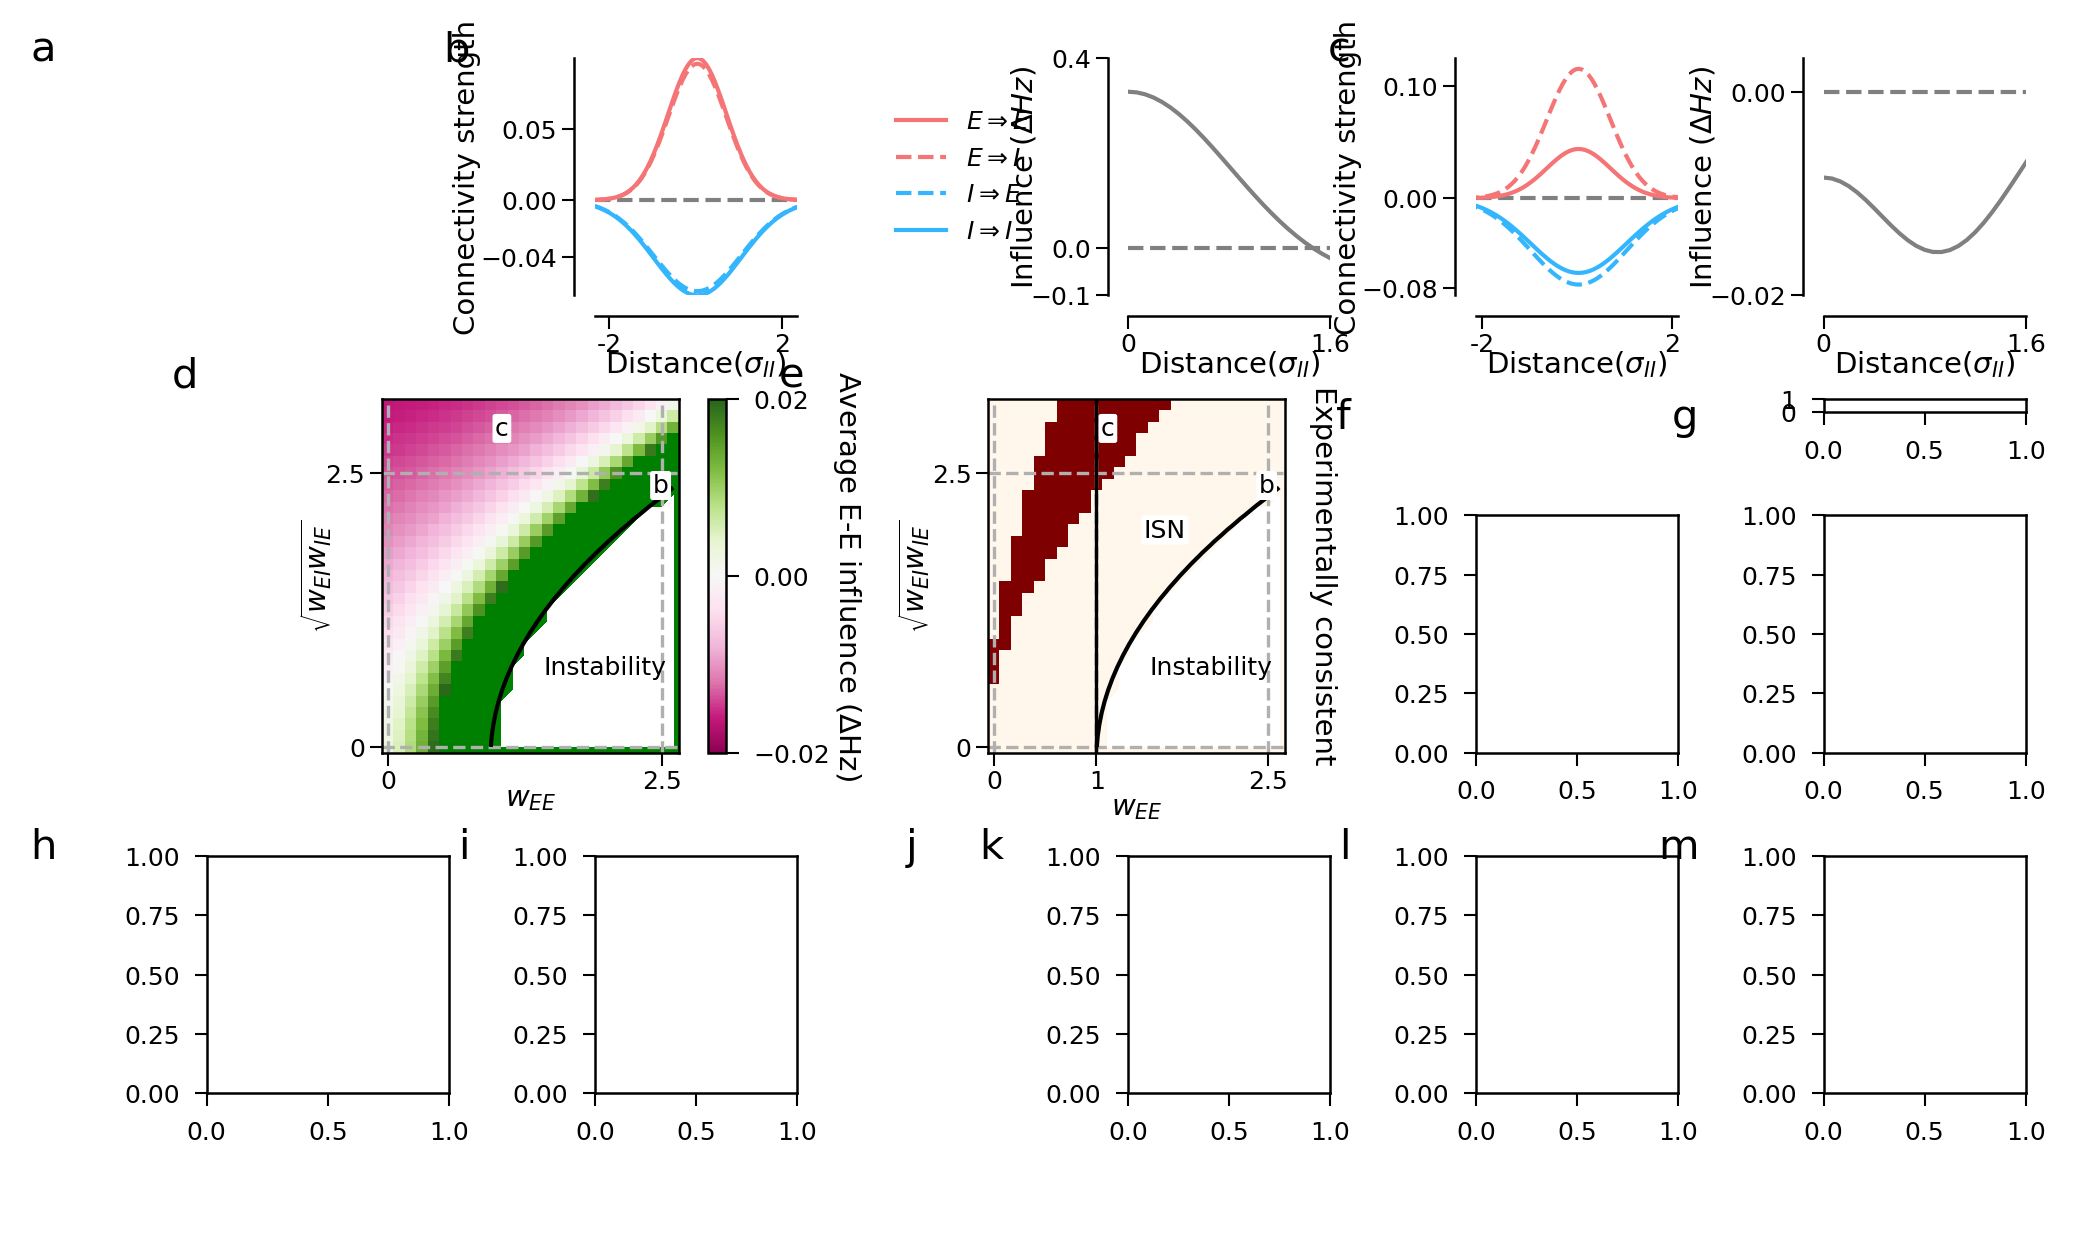

In [11]:
name = 'e'

BiologicallyPlausibleEE,StableEE = get_plausible_bool()


X, Y = np.meshgrid(Wee,Wei)

axes[name].set_yticks([0.1,2.5], ['$0$','$2.5$'])
c = axes[name].pcolormesh(X, Y,BiologicallyPlausibleEE, shading='auto', cmap='OrRd')
cb.ax.tick_params()  

axes[name].grid(True, which='both', linestyle='--', alpha=1)

axes[name].set_xticks([0.1,1,2.5], ['$0$','$1$','$2.5$'])
axes[name].set_yticks([0.1,2.5], ['$0$','$2.5$'])


axes[name].grid(False, which='both', linestyle='--', alpha=1)
axes[name].set_ylabel(r'$\sqrt{weiwie}$',labelpad=-2)
axes[name].set_xlabel('$wee$',labelpad=-2)
Instmask = np.ma.masked_where(StableEE <= 1, StableEE)


axes[name].contourf(X, Y, Instmask, levels=[1, StableEE.max()], colors='white')


axes[name].axvline(x=1, linestyle='--', color='gray', linewidth=0.8)
axes[name].contour(X, Y, StableEE, levels=[1], colors='black', linewidths=1)

axes[name].set_ylabel(r'$\sqrt{w_{EI}w_{IE}}$',labelpad=0)
axes[name].set_xlabel('$w_{EE}$',labelpad=0)
axes[name].set_aspect('equal')
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)

axes[name].axvline(x=1, color='black', linestyle='-', linewidth=0.8)
# axes[name].set_title('Experimentally consistent',pad=0)
axes[name].text(
    1.08, 0.5, "Experimentally consistent",            # x>1 moves to the right of plot
    transform=axes[name].transAxes,          # axis-relative coordinates (0–1)
    rotation=-90,                            # vertical text
    va='center', ha='left'
)

axes[name].text(
    1.6, 2, 'ISN',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)

axes[name].text(
    2.49, 2.39, 'b',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)
axes[name].text(
    1.1, 2.89, 'c',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)
axes[name].text(
    2, 0.8, 'Instability',
    fontsize=6,
    color='black',
    ha='center', va='center'
)


fig

# Constrasts

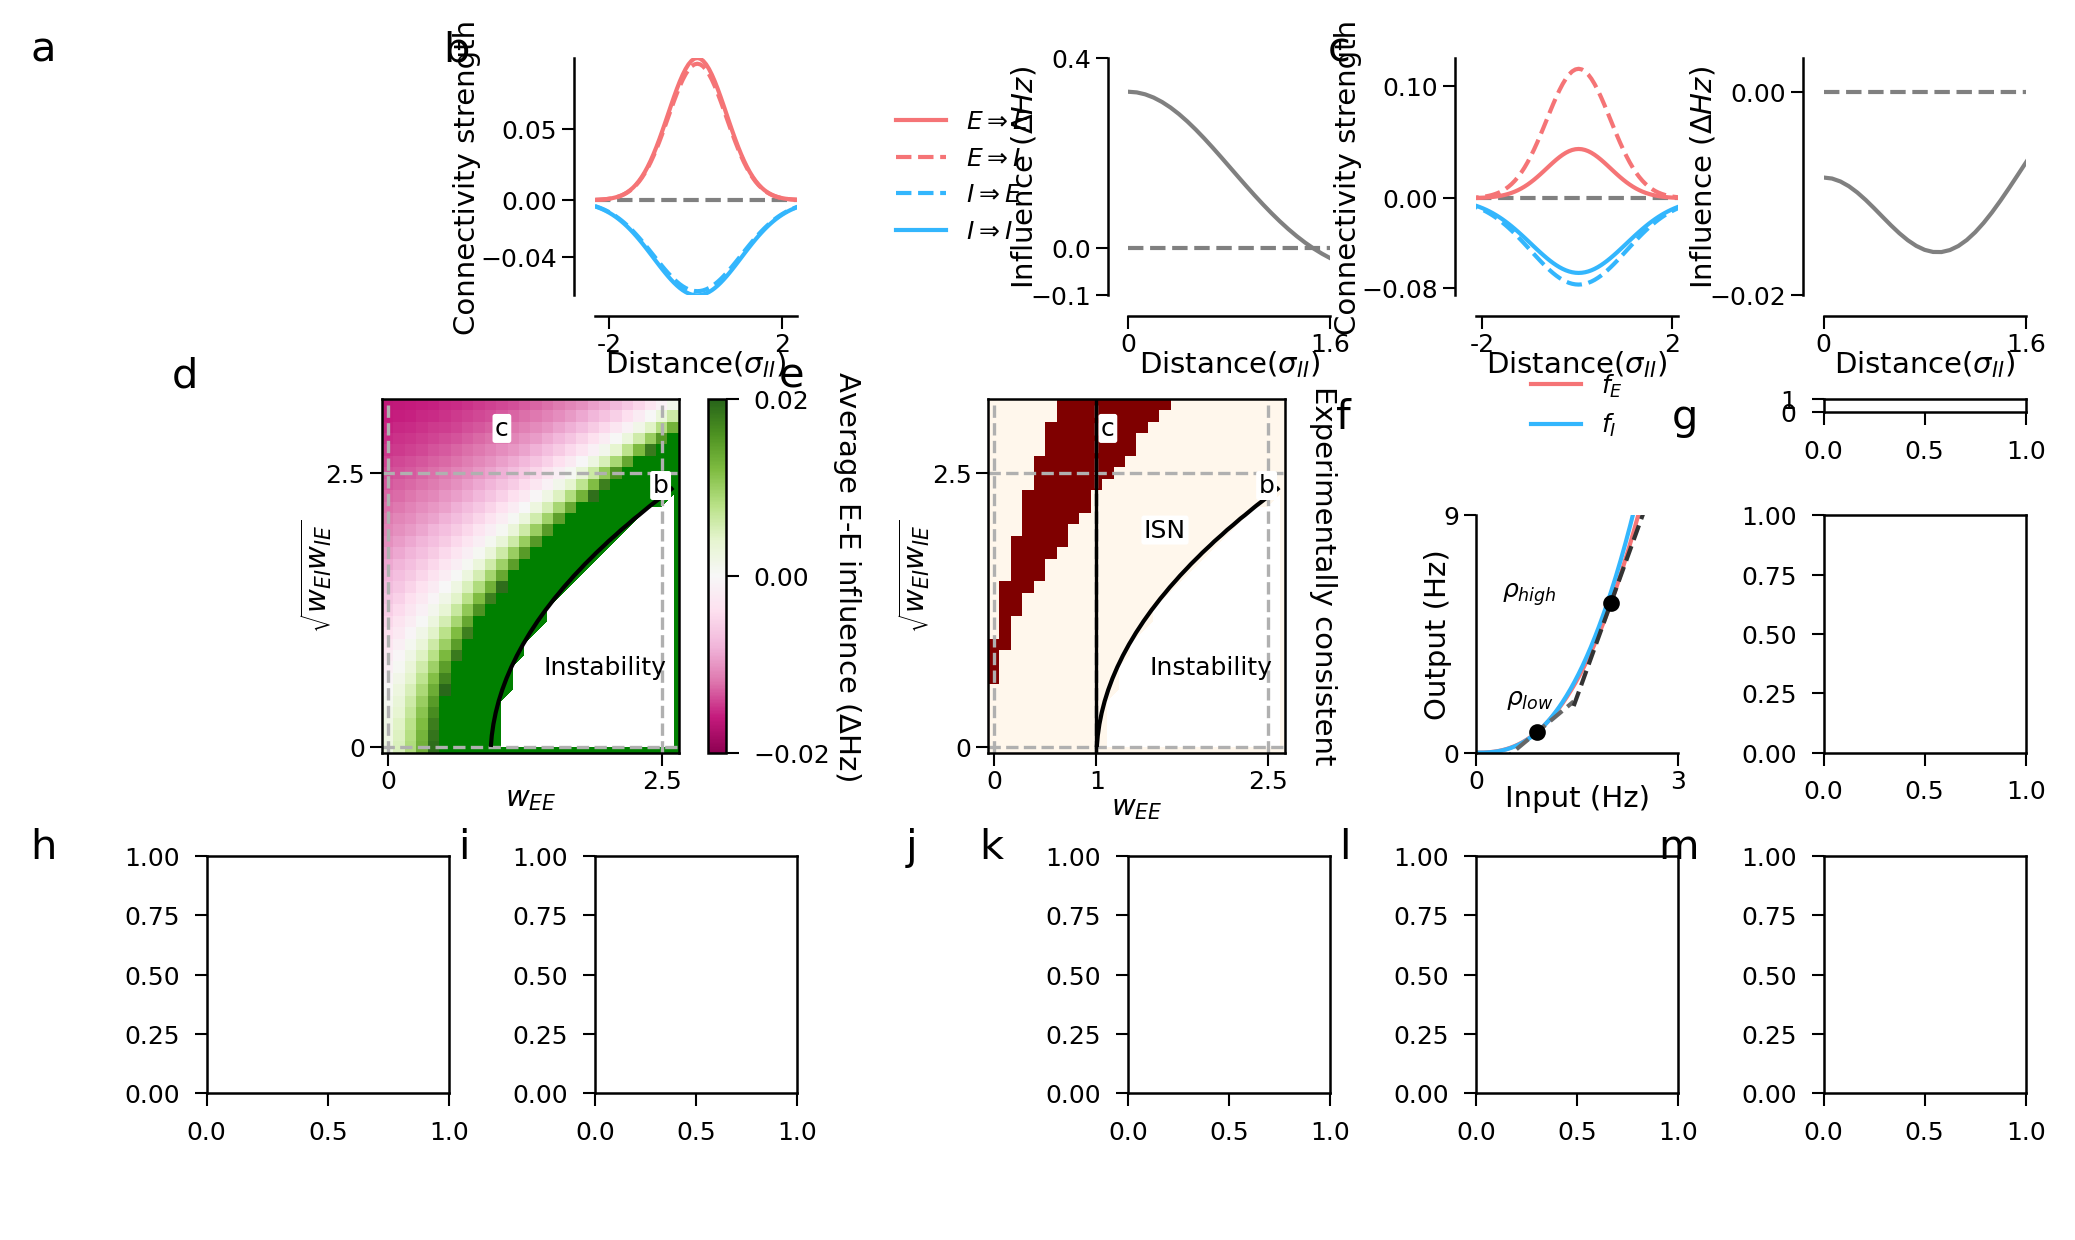

In [12]:
name = 'f'

# Turn off top and right spines
for side in ['top', 'right']:
    axes[name].spines[side].set_visible(False)

# Main curve
p = 2.5
x = np.linspace(0, 3, 300)
y1 = x**p
y2 = x**(p+0.1)
axes[name].plot(x, y1, color='#F57476',label=r'$f_E$')
axes[name].plot(x, y2, color='#33B6FD',label=r'$f_I$')

# Points for tangent lines
x_tangent_points = [0.9, 2.0]
colors = [ '#666666', '#333333']  # More visible greys

for x0, color in zip(x_tangent_points, colors):
    y0 = x0**p
    slope = p * (x0**(p-1))
    
    dx = 0.55  # Length of the line segment
    x_line = np.linspace(x0 - dx, x0 + dx, 100)
    y_line = y0 + slope * (x_line - x0)

    axes[name].plot(x_line, y_line, linestyle='--', color=color, linewidth=1)

    # Optional: Mark the point of tangency
    axes[name].plot(x0, y0, 'o', color='k', markersize=3)

# Optional: Set axis limits to ensure everything is visible
axes[name].set_xlim(0, 3)
axes[name].set_ylim(0, 9)
axes[name].set_xticks([0,3])
axes[name].set_yticks([0,9])

axes[name].set_xlabel('Input (Hz)',labelpad=-2)
axes[name].set_ylabel('Output (Hz)',labelpad=-2)
axes[name].tick_params(axis='x', pad=1)
axes[name].tick_params(axis='y', pad=1)

axes[name].text(
    0.8, 2, r'$\rho_{low}$',
    fontsize=6,
    color='black',
    ha='center', va='center'
)

axes[name].text(
    0.8, 6, r'$\rho_{high}$',
    fontsize=6,
    color='black',
    ha='center', va='center'
)

axes['f_legend'].legend(*axes['f'].get_legend_handles_labels(), loc='center', fontsize=6, frameon=False)

fig

/Users/fionakong/Downloads/kaschube-lab/Influence_mapping/code_clean/Model/ring.py:1082: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  opto = torch.tensor(opto,dtype=torch.float32)


15.0


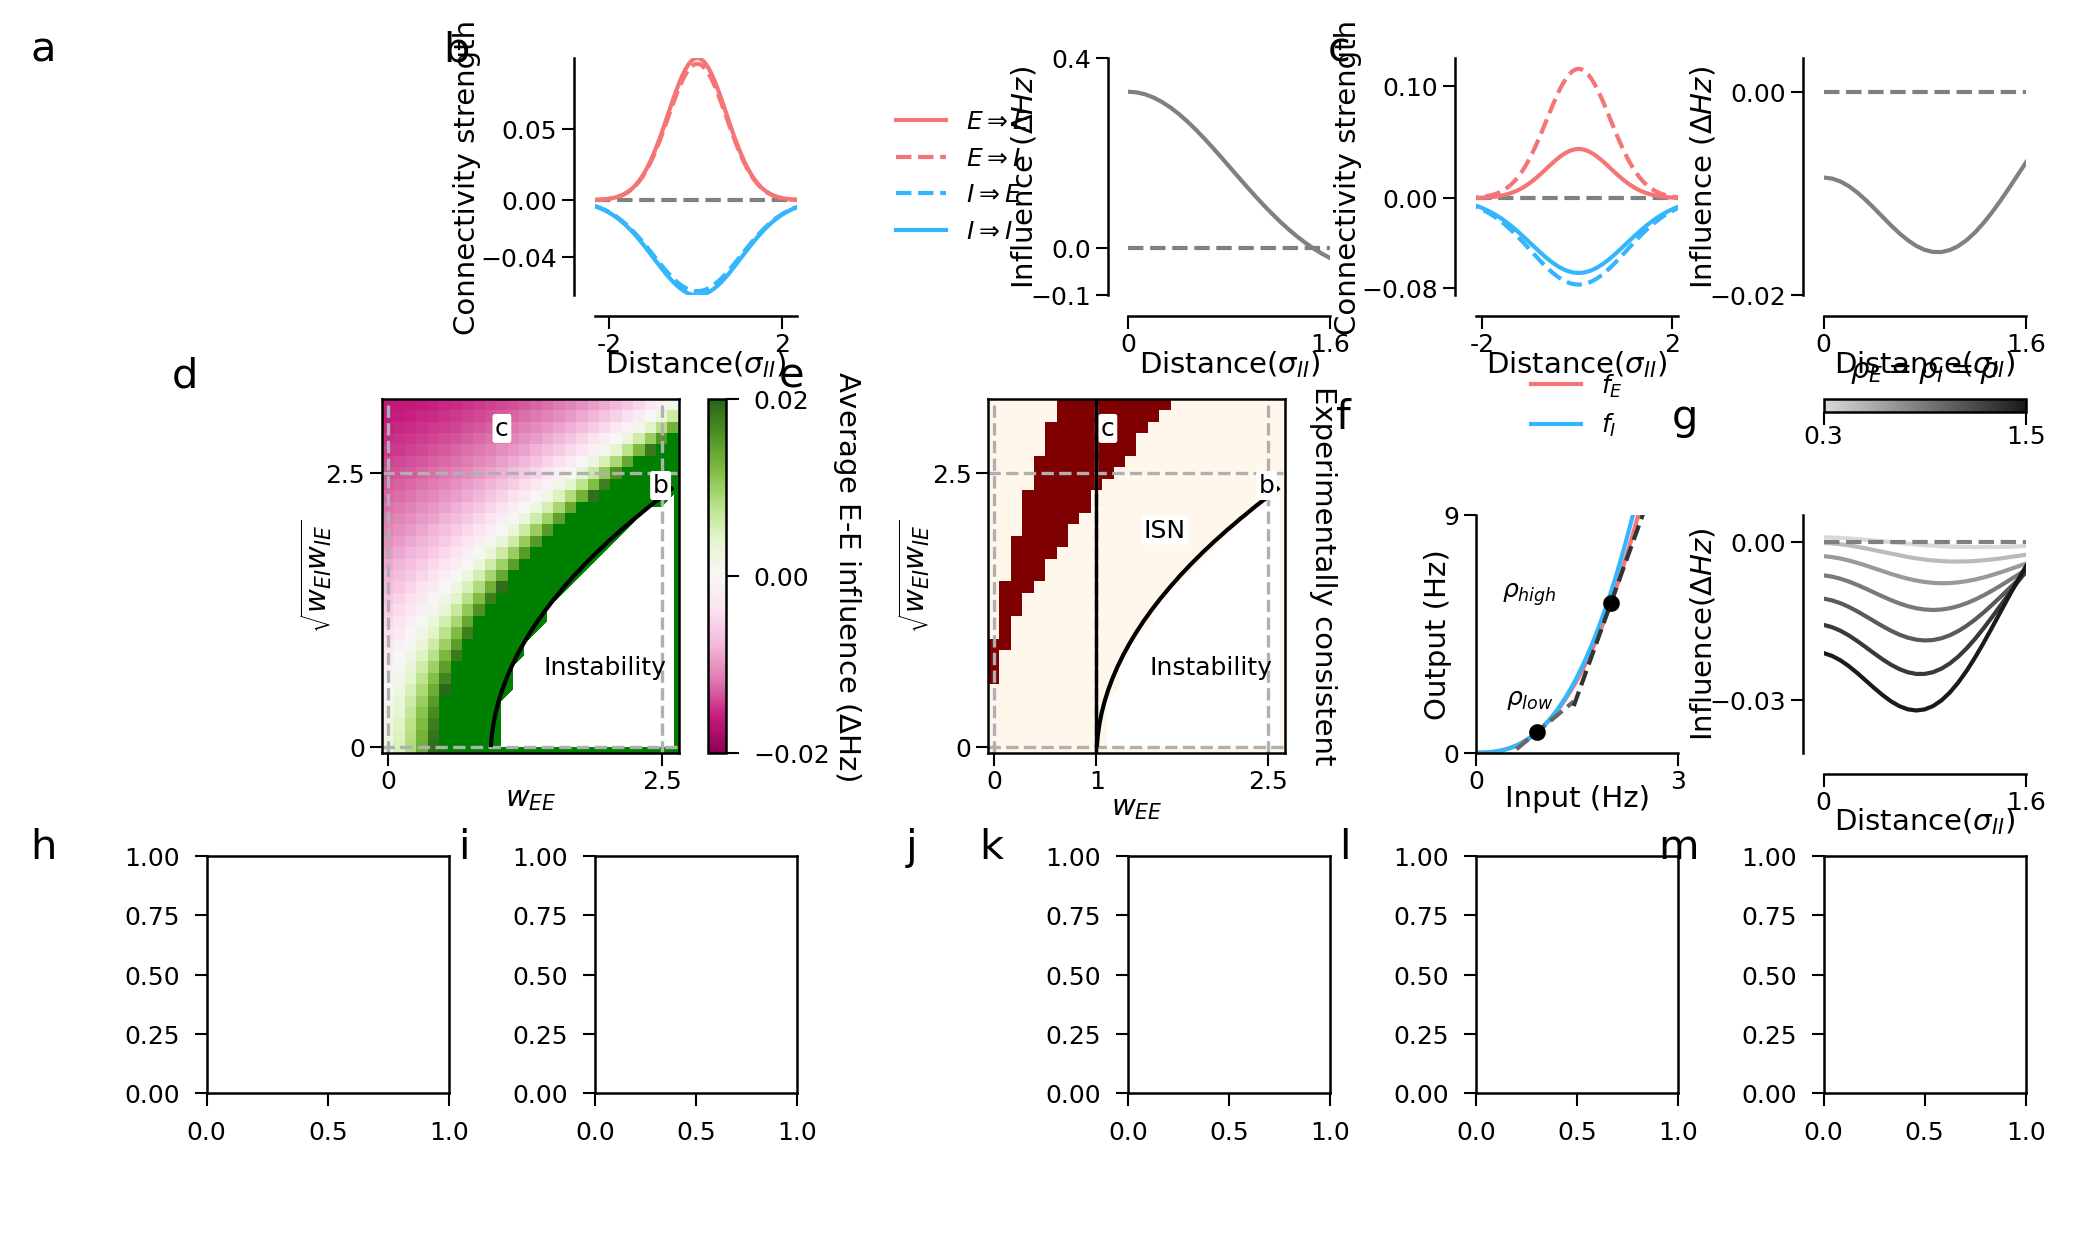

<Figure size 2067x1440 with 0 Axes>

In [13]:
name = 'g'

gain_curves = compute_infl_gain()   # list/tuple of 7 curves
gain_curves = [np.asarray(curve, dtype=float) for curve in gain_curves]

grayscale = LinearSegmentedColormap.from_list(
    "custom_gray", ['#d9d9d9', '#1a1a1a']
)

n = len(gain_curves)
RTOT = np.column_stack(gain_curves)   # shape: (n_points, n_curves)

norm = Normalize(vmin=0, vmax=n - 1)
cmap = grayscale

ax = axes[name]

for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_position(('outward', 5))
ax.spines['left'].set_position(('outward', 5))

for i, curve in enumerate(gain_curves):
    ax.plot(curve, color=cmap(norm(i)))

ax.set_ylabel(r"Influence($\Delta Hz$)", labelpad=-2)
ax.set_xlabel(r"Distance($\sigma_{II}$)", labelpad=-2)

ax.axhline(y=0.00, color='grey', linestyle='--')
print(Lambda)
ax.set_xticks([0.0, 1.6 * Lambda])
ax.set_xlim([0, 1.6 * Lambda])
ax.set_yticks([-0.03, 0.00])
ax.set_ylim([-0.04, 0.005])
ax.set_xticklabels(['0', '1.6'])
ax.tick_params(axis='x', pad=1)
ax.tick_params(axis='y', pad=1)

frequency = np.array([0.3, 1.5])
freq_norm = Normalize(vmin=frequency.min(), vmax=frequency.max())
sm = cm.ScalarMappable(norm=freq_norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    cax=axes['g_legend'],
    orientation='horizontal',
    ticks=[0.3, 1.5]
)
cbar.set_label(r'$\rho_E=\rho_I=\rho$', labelpad=5, rotation=0, ha='center')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(axis='x', pad=0)

fig

# Ncorr

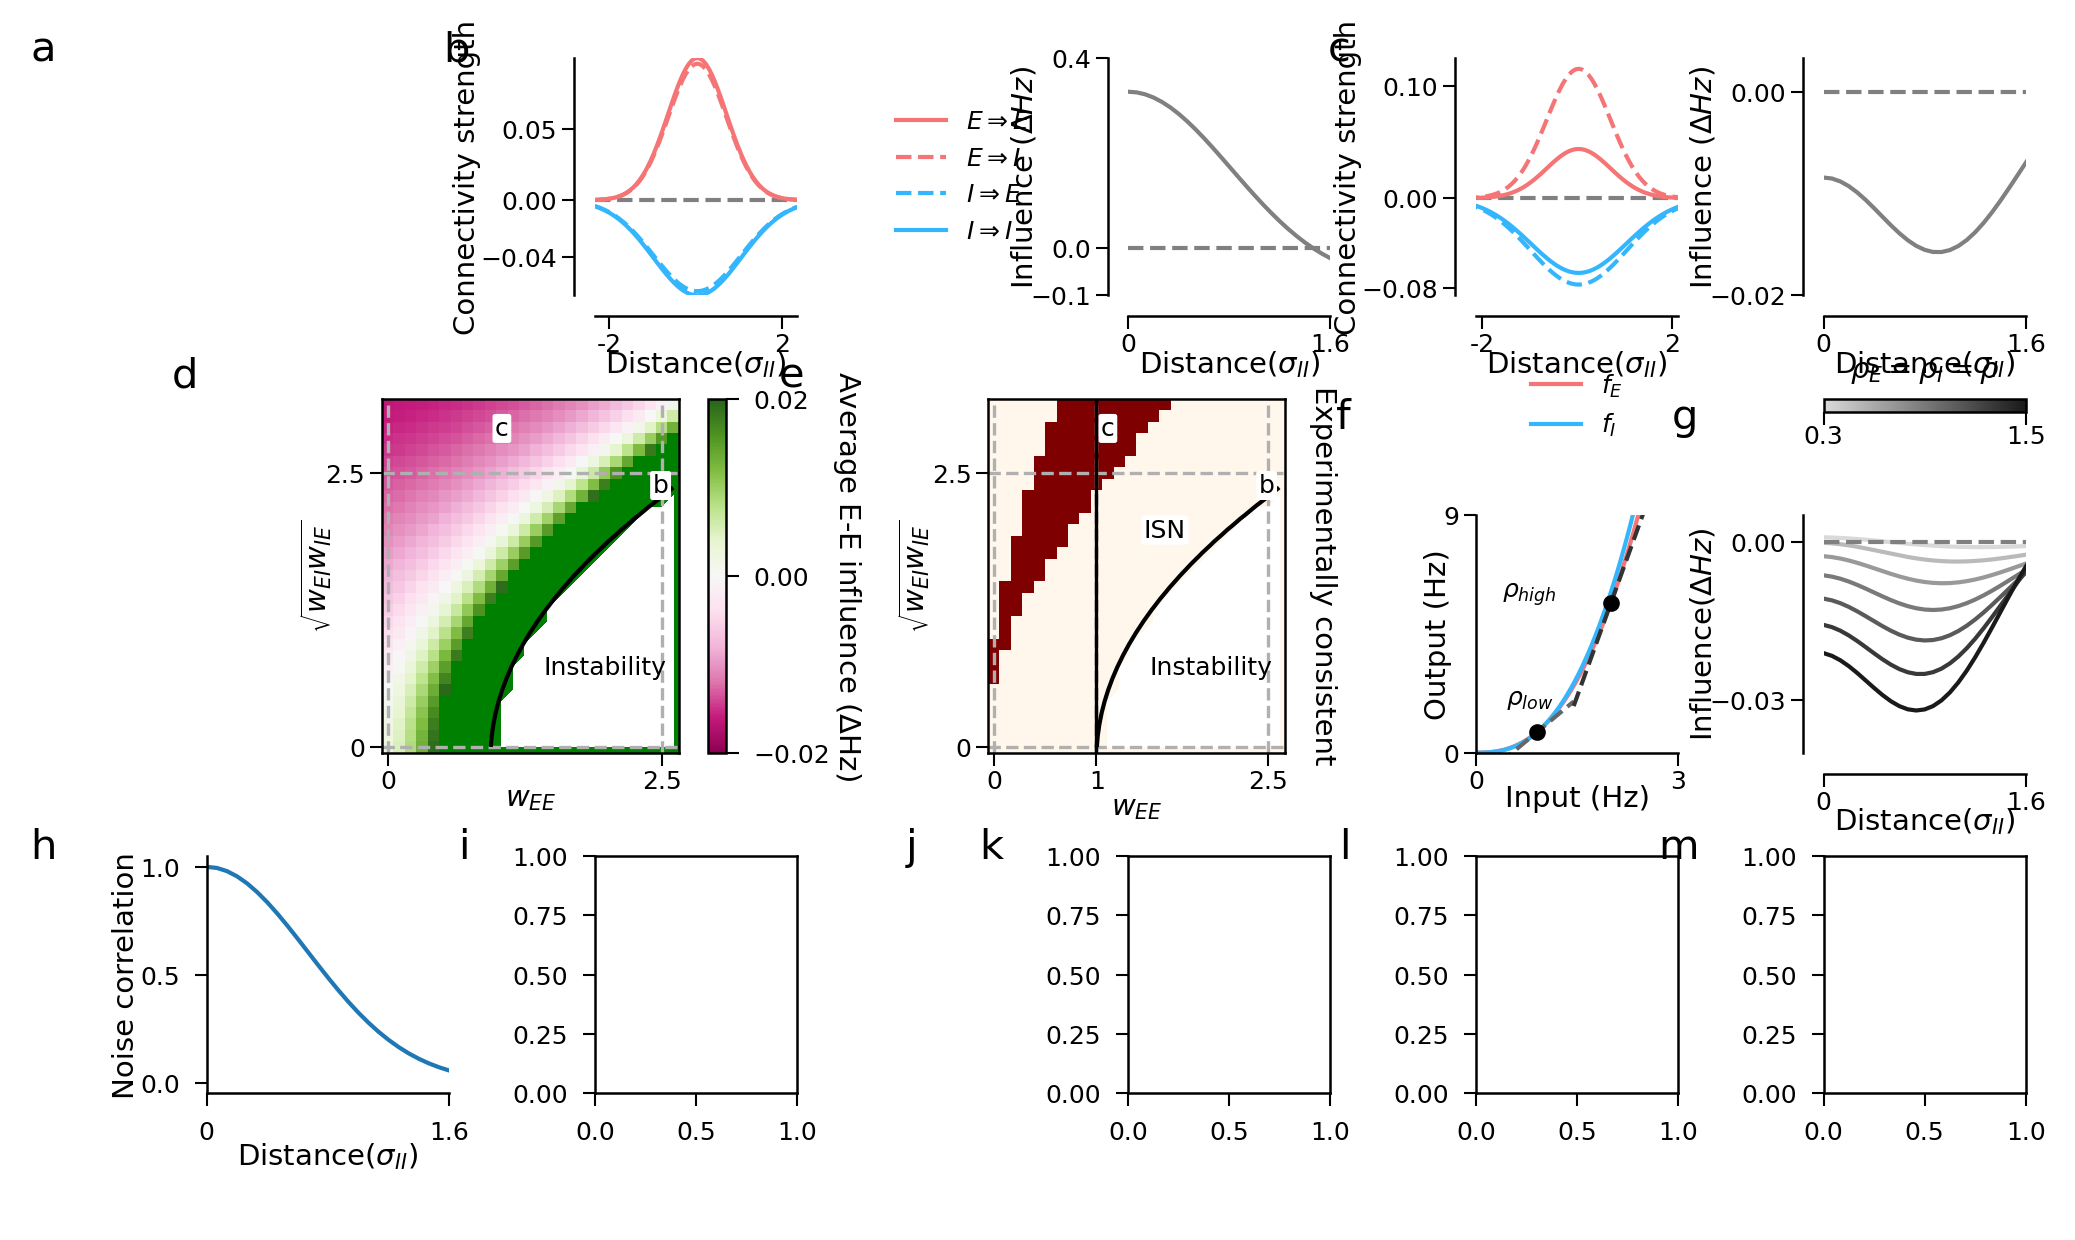

In [14]:
name='h'

dist, ncorr = get_ncorr_schem()

for side in ['top','right']:
    axes[name].spines[side].set_visible(False)

axes[name].plot(dist,ncorr)
axes[name].set_xlim([0,1.6*10*1.5])
axes[name].set_xticks([0,1.6*10*1.5])
axes[name].set_xticklabels([ '0', '1.6'])
axes[name].set_ylabel("Noise correlation",labelpad=0)
axes[name].set_xlabel(r'Distance($\sigma_{II}$)',labelpad=-1)

fig

/Users/fionakong/Downloads/kaschube-lab/Influence_mapping/code_clean/Model/ring.py:1082: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  opto = torch.tensor(opto,dtype=torch.float32)


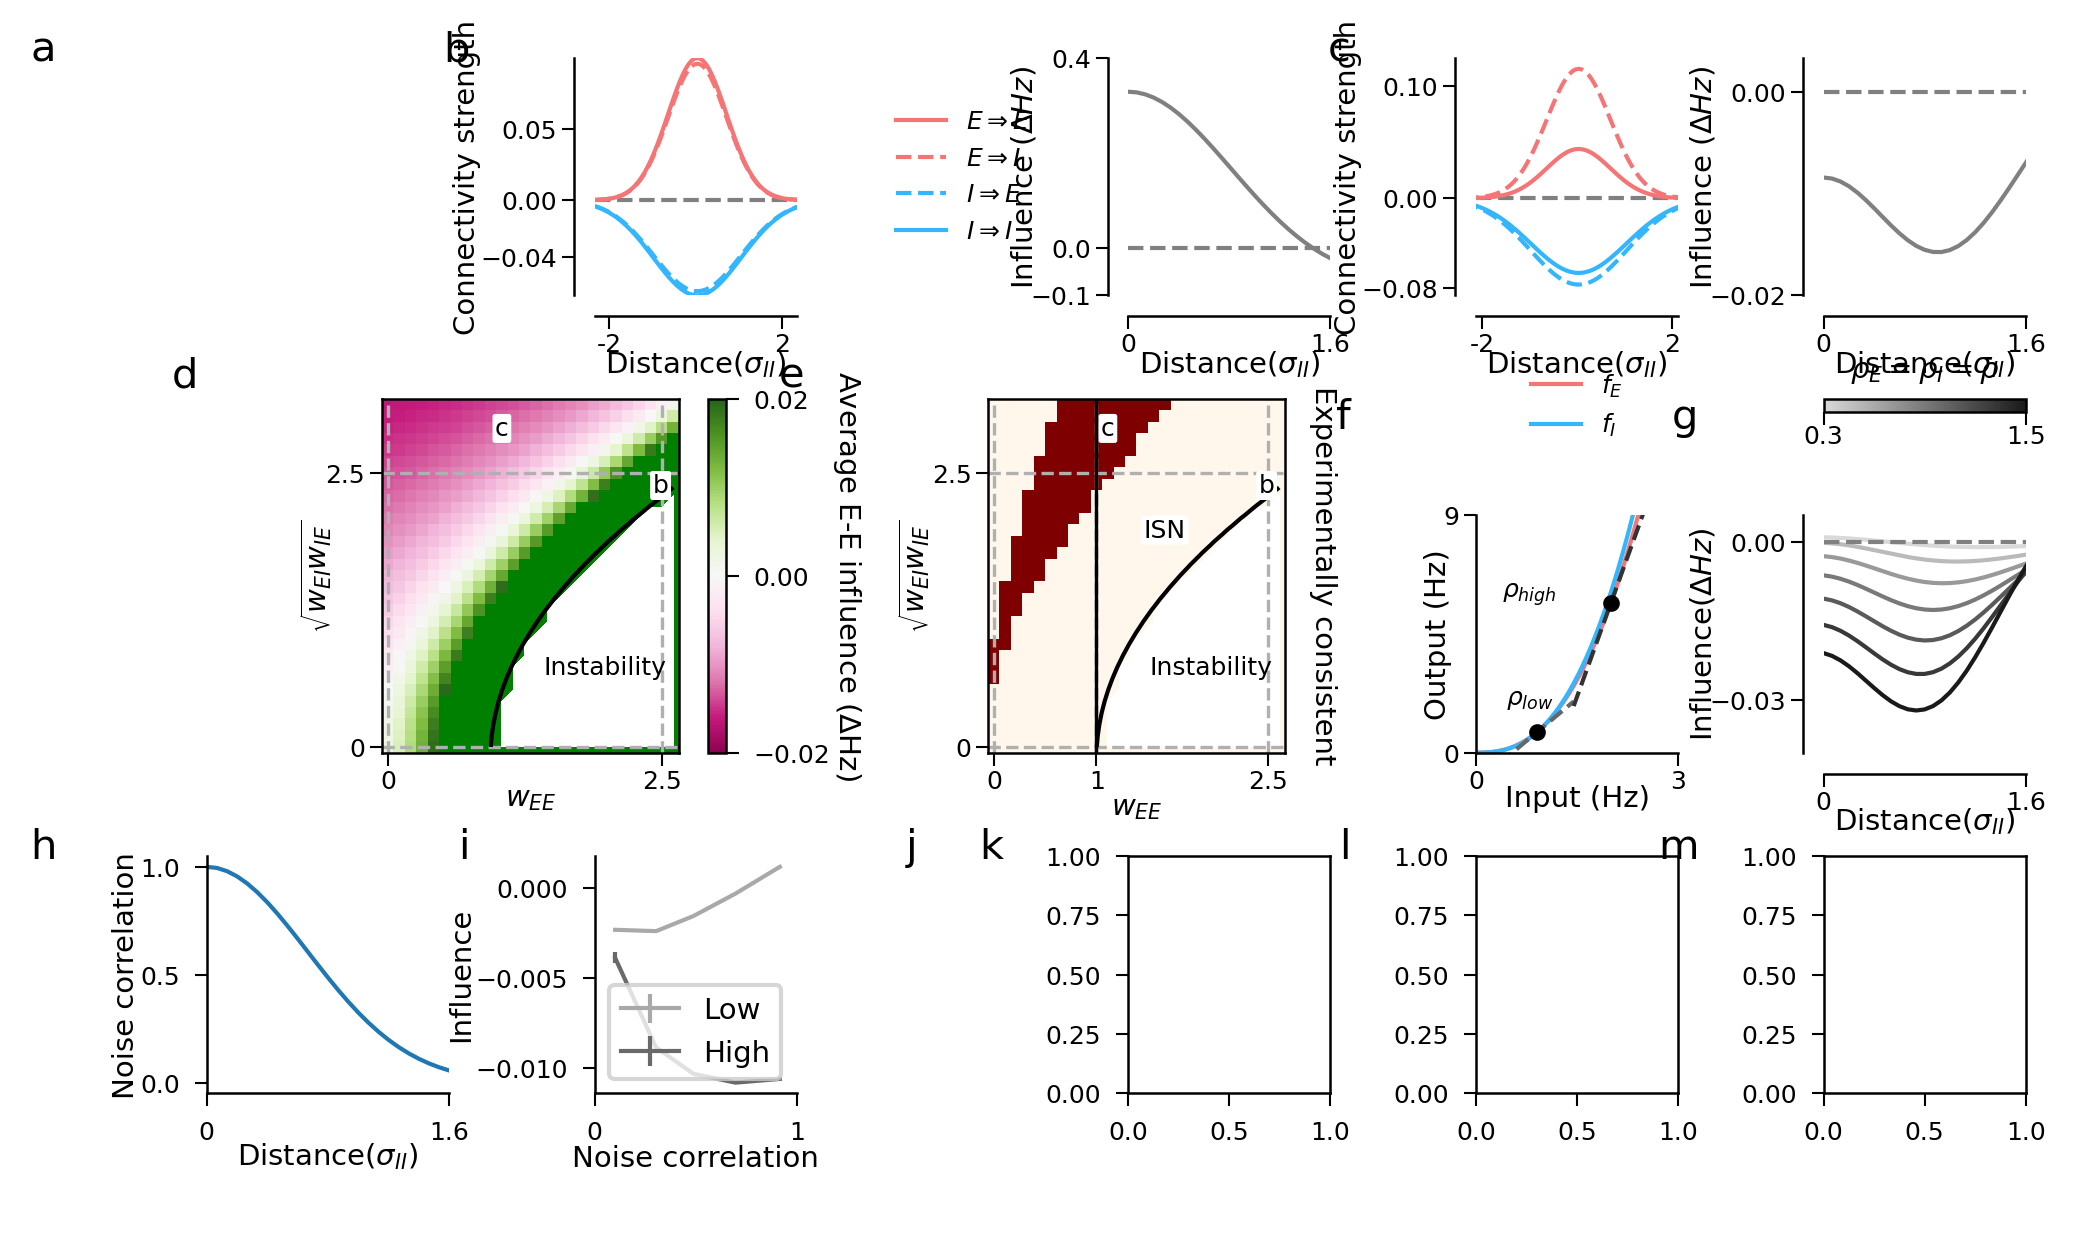

In [15]:
name='i'

ncorr, avg_infl_low, std_infl_low, avg_infl_high, std_infl_high = get_infl_vs_ncorr()

for side in ['top','right']:
    axes[name].spines[side].set_visible(False)

axes[name].errorbar(ncorr,  avg_infl_low,  yerr=std_infl_low, color='darkgrey', label='Low')
axes[name].errorbar(ncorr,  avg_infl_high,  yerr=std_infl_high,color='dimgrey', label='High')
# axes[name].set_xlim([0,1])
axes[name].set_xticks([0,1])
# axes[name].set_xticklabels([ '0', '1.6'])
axes[name].set_ylabel("Influence",labelpad=0)
axes[name].set_xlabel('Noise correlation',labelpad=0)

axes[name].legend()

fig

# slopes

Done


/opt/anaconda3/envs/myenv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


0.3242105263157895 1.4763157894736842
0.32125000000000004 1.3587500000000001


/var/folders/z8/675cf8pn6s53_cqmkl8jcnyc0000gq/T/ipykernel_12649/3586142371.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('coolwarm').copy()


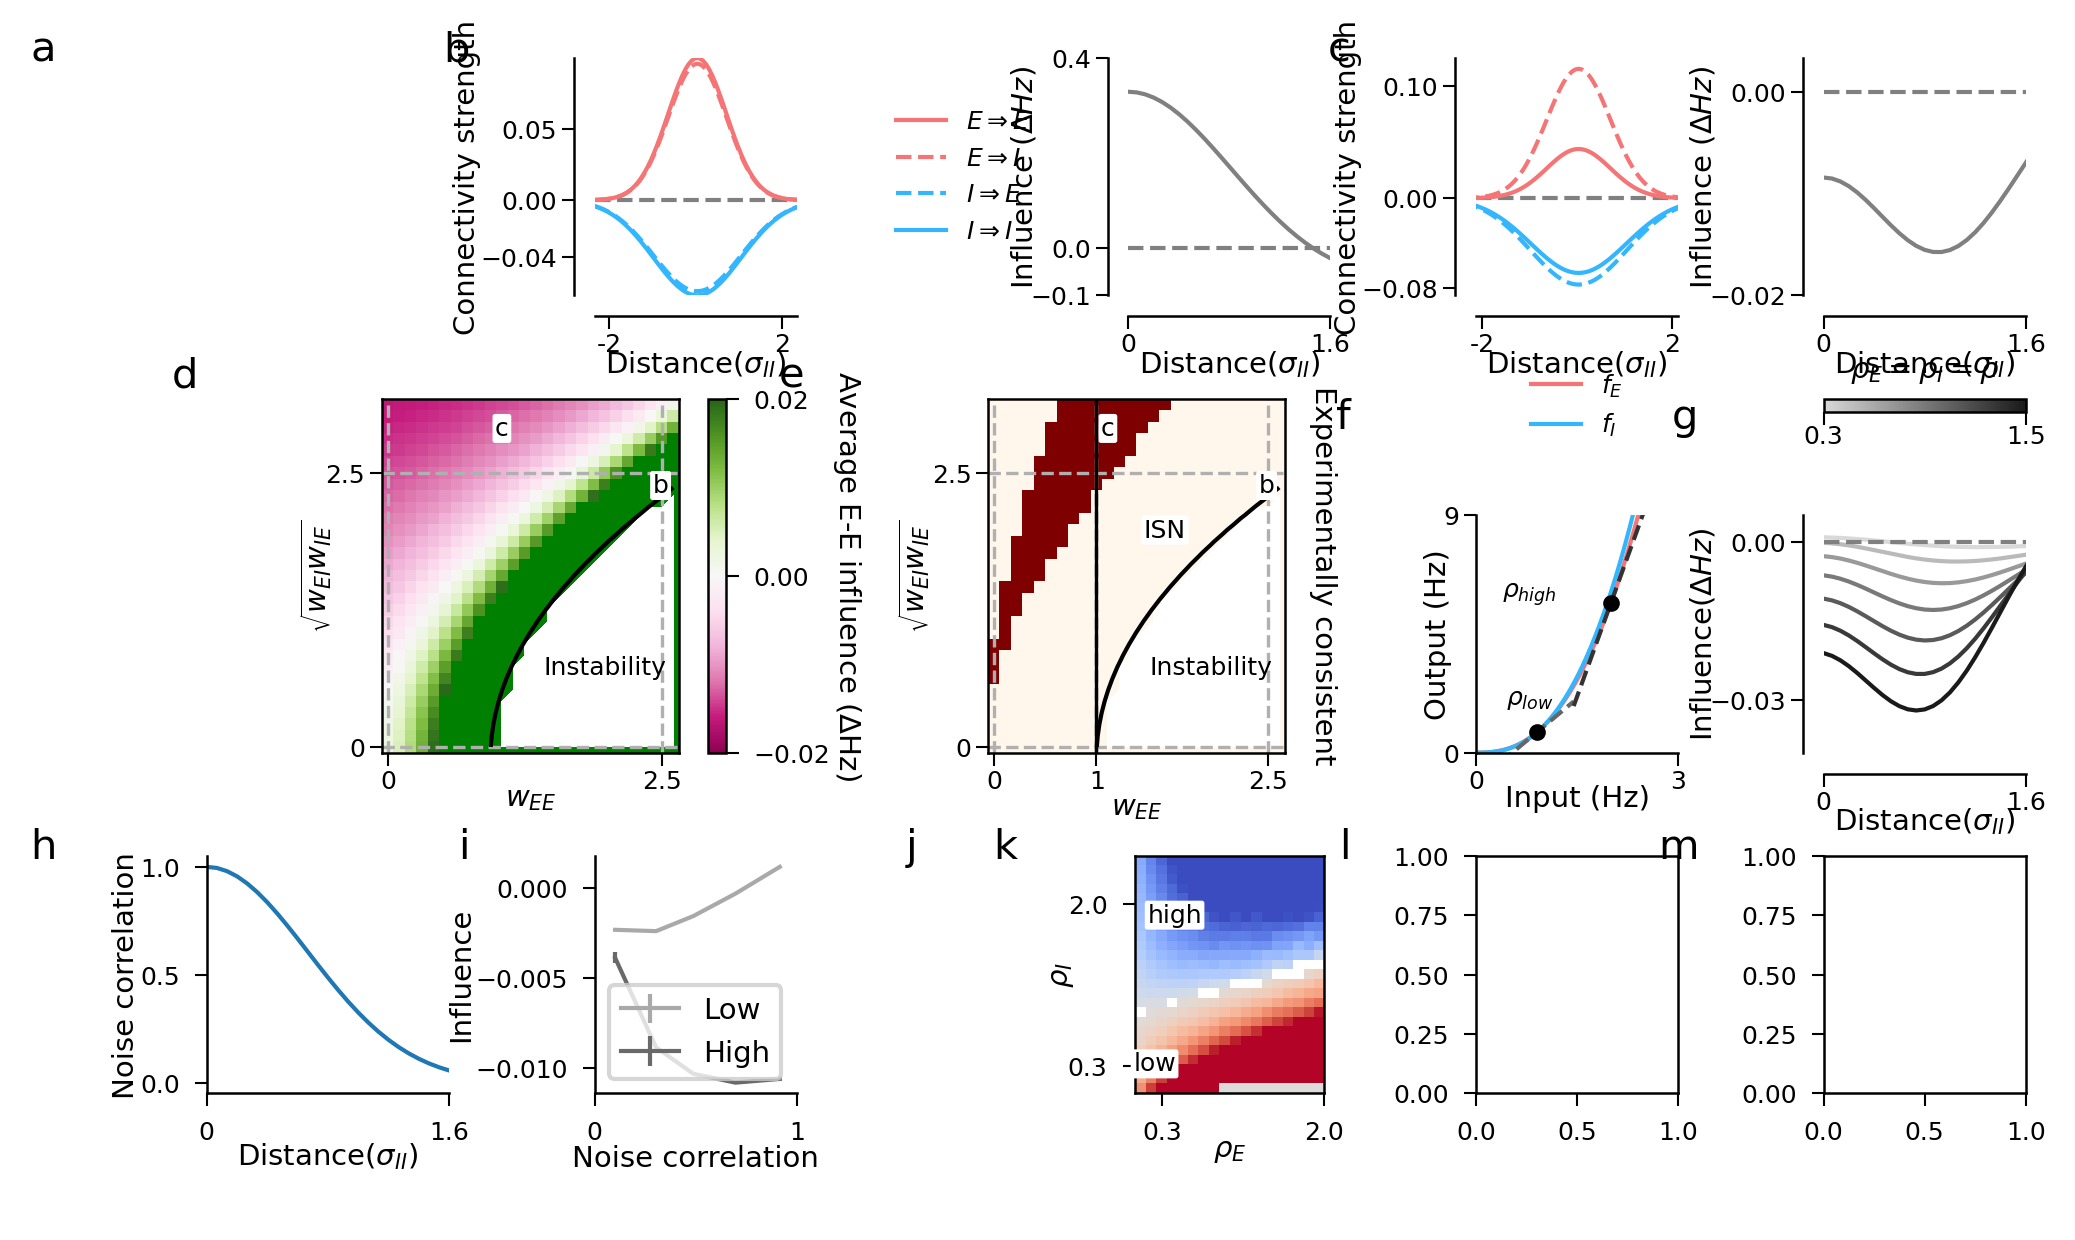

In [16]:
name = 'k'
slope_map, slopes_e, slopes_i,pvals = fit_infl_ncorr_slopes()

# Make sure slopes are sorted if you want proper axis labeling
x_vals = slopes_e
y_vals = slopes_i

# imshow expects extent = [x_min, x_max, y_min, y_max]
print(x_vals[3],x_vals[-6])
print(y_vals[3],y_vals[-12])

plot_data = slope_map[2:, :].T.copy()

# Slice pvals same way as slope_map, THEN transpose
sig_mask_sliced = (pvals > 0.0005)[2:, :].T
plot_data[sig_mask_sliced] = np.nan

# Colormap with white for NaNs
cmap = mpl.cm.get_cmap('coolwarm').copy()
cmap.set_bad(color='white')

im = axes[name].imshow(
    plot_data,
    extent=[x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]],
    aspect='auto',
    origin='lower',
    norm=mpl.colors.TwoSlopeNorm(vmin=-0.01, vcenter=0, vmax=0.02),
    cmap=cmap
)

# Set axis labels (optional)
axes[name].set_xlabel(r'$\rho_E$',labelpad=-2)
axes[name].set_ylabel(r'$\rho_I$',labelpad=-2)
axes[name].set_aspect('equal')


significant_mask = (pvals > 0.00005).T  # Transpose to match imshow orientation


axes[name].set_xticks([0.3,2])
axes[name].set_yticks([0.3,2])

nan_mask = np.isnan(slope_map[2:, :].T)  # shape (nx, ny)

# X edges correspond to the 2nd dimension (ny)
x_edges = np.linspace(x_vals[3], x_vals[-6], nan_mask.shape[1] + 1)
# Y edges correspond to the 1st dimension (nx)
y_edges = np.linspace(y_vals[3], y_vals[-12], nan_mask.shape[0] + 1)

axes[name].pcolormesh(
    x_edges, y_edges, nan_mask.astype(float),
    hatch='///', edgecolors='gray', facecolors='none', linewidth=0
)
axes[name].text(
    0.22, 0.32, 'low',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)


axes[name].text(
    0.43, 1.88, 'high',
    fontsize=6,
    color='black',
    ha='center', va='center',
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
)


fig

/var/folders/z8/675cf8pn6s53_cqmkl8jcnyc0000gq/T/ipykernel_12649/2207956496.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 2067x1440 with 21 Axes> than <Figure size 2067x1440 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=axes[name], ticks=[-0.01,0, 0.02])


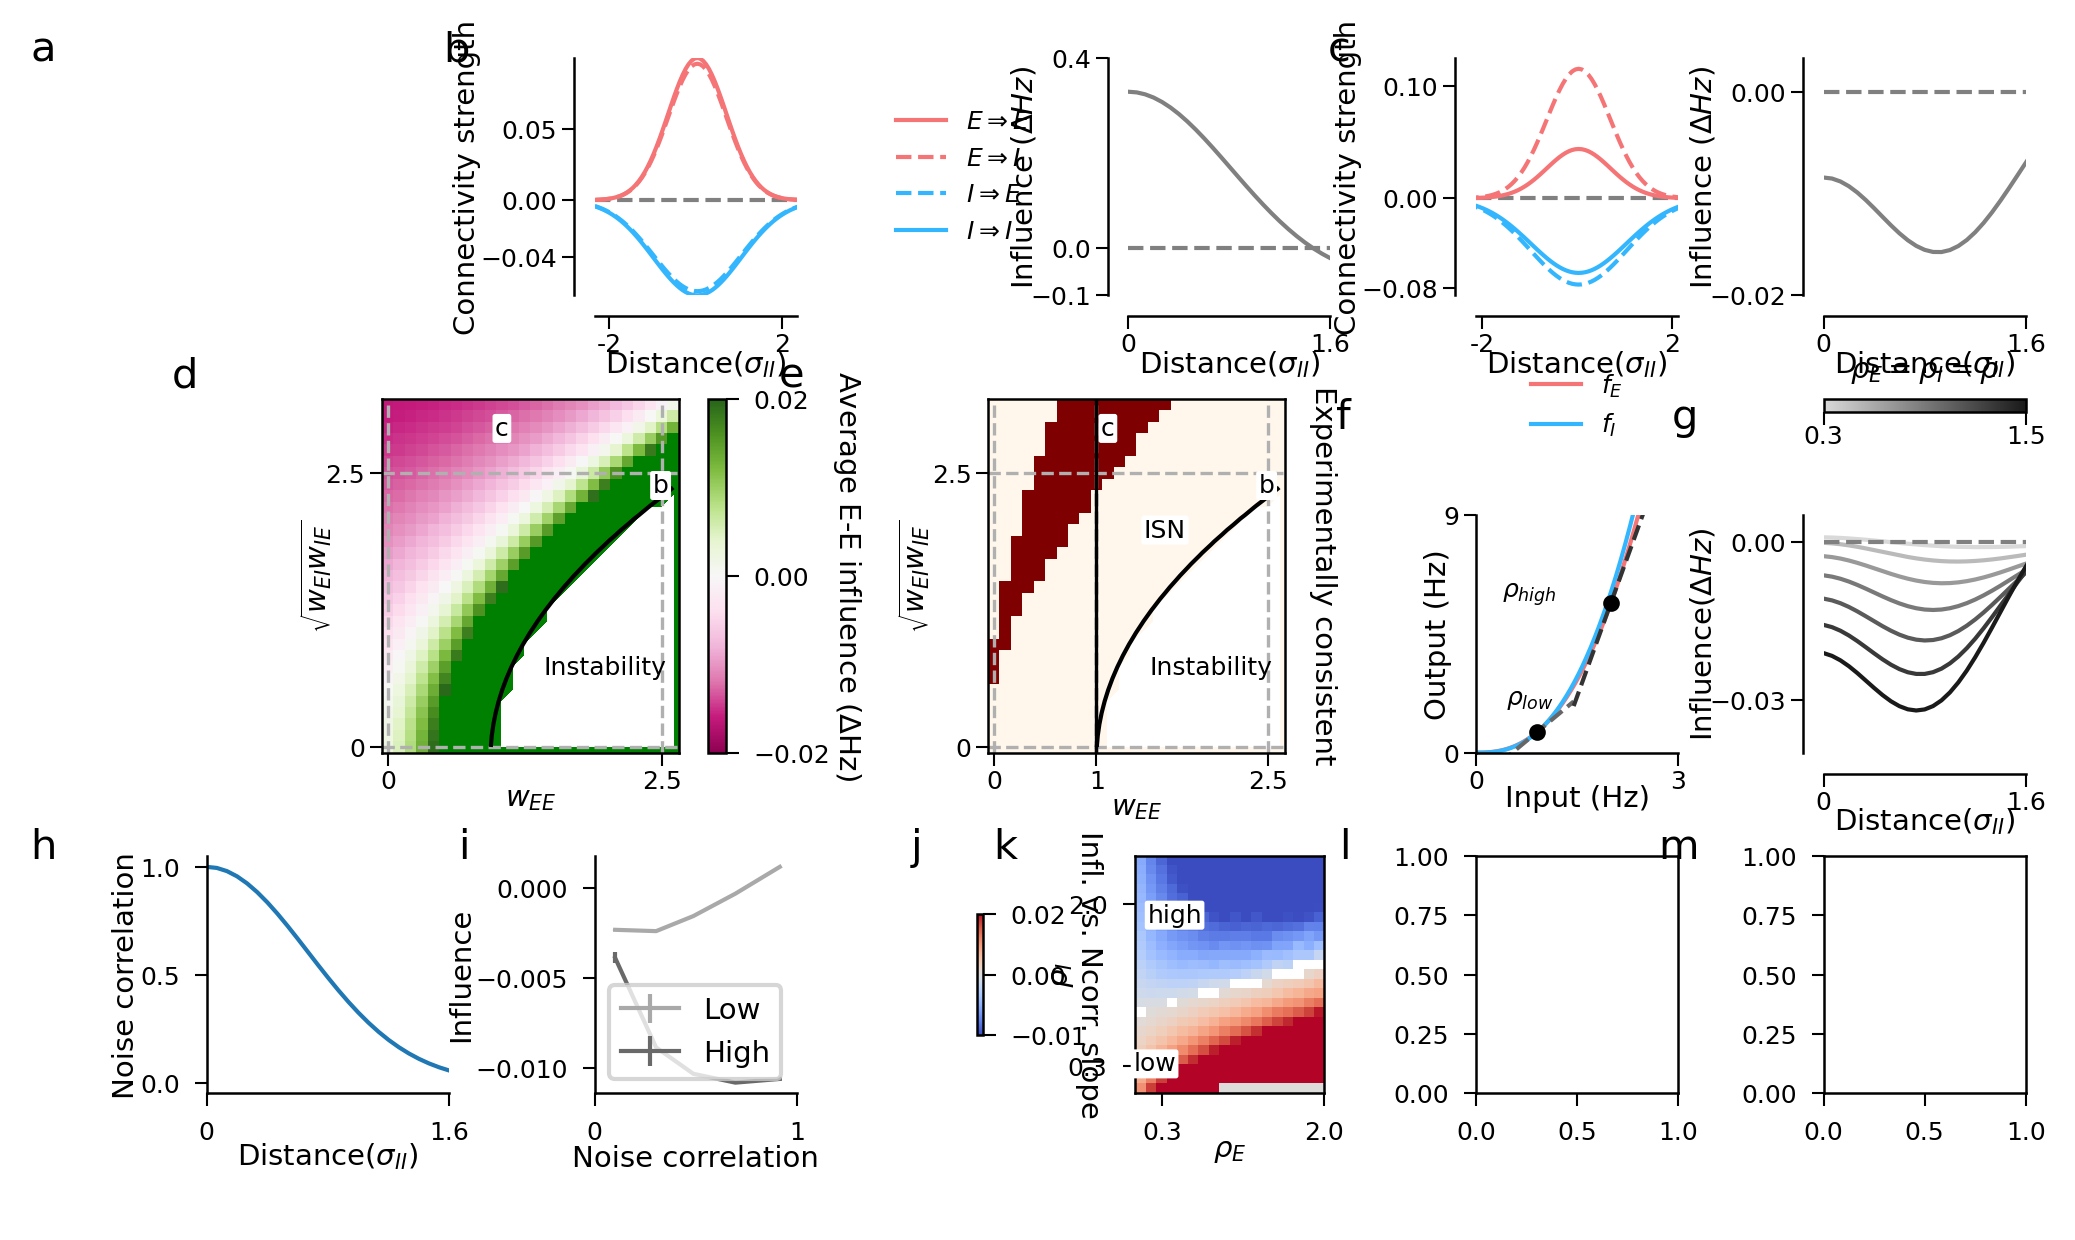

<Figure size 2067x1440 with 0 Axes>

In [17]:
name = 'j'
cbar = plt.colorbar(im, ax=axes[name], ticks=[-0.01,0, 0.02])
cbar.set_label('Infl. vs. Ncorr. slope',rotation=270)
fig

In [18]:
name = 'm'

far, near = load_4n_2d()

axes['name']



NameError: name 'load_4n_2d' is not defined

# Save

In [ ]:
# import datetime
# if 'dldevel' in os.path.expanduser("~"):
#     fig_path = ''
# else:
#     fig_path = ''
# draft_id = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# fig.savefig(fig_path + "fig_model{}.svg".format(draft_id), dpi=300,bbox_inches='tight')
# fig.savefig(fig_path + "fig_model{}.pdf".format(draft_id), dpi=300,bbox_inches='tight')